In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F
import torch.nn as nn
from tqdm import tqdm
import yfinance as yf
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, accuracy_score, f1_score, r2_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import RFECV
import warnings

warnings.filterwarnings("ignore", category=UserWarning)


# Reading files

In [2]:
DAILY_DIRECTORY = Path("daily")

shape: (6, 2)
┌───────────────────────┬────────┐
│ source                ┆ len    │
│ ---                   ┆ ---    │
│ str                   ┆ u32    │
╞═══════════════════════╪════════╡
│ yahoo.com             ┆ 582763 │
│ reuters.com           ┆ 475871 │
│ bloomberg.com         ┆ 87256  │
│ cnbc.com              ┆ 76054  │
│ thomsonreuters.com    ┆ 504    │
│ thomsonreuters.com.au ┆ 16     │
└───────────────────────┴────────┘


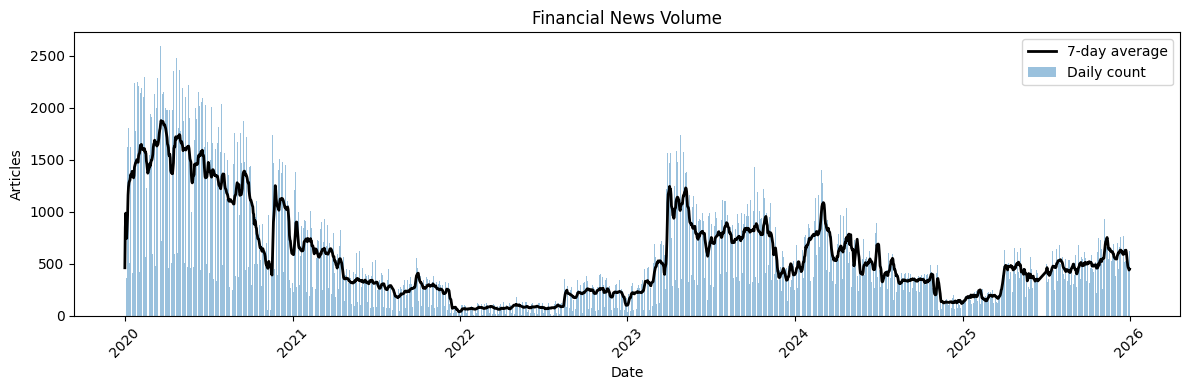

In [3]:
files = DAILY_DIRECTORY.glob("*.parquet")
df = pl.scan_parquet(files)

fin_df = (
    df
    .filter(
        pl.any_horizontal(
            pl.col("source").str.contains(r"cnbc.com|reuters.com|(?:^|\.)bloomberg.com"),
            (pl.col("url").str.contains(r"finance\.yahoo") & pl.col("source").str.contains("yahoo.com"))
        )
    )
    .with_columns(pl.col("datetime").dt.date().alias("date"))
)

daily_counts = fin_df.group_by("date").len().sort("date")
result = daily_counts.collect(engine="streaming")
result_pd = result.to_pandas()
result_pd["rolling_7d"] = result_pd["len"].rolling(7, min_periods=1).mean()

print(fin_df.group_by("source").len().sort(by="len", descending=True).collect(engine="streaming"))

plt.figure(figsize=(12, 4))
plt.bar(result_pd["date"], result_pd["len"], label="Daily count", alpha=0.45)
plt.plot(result_pd["date"], result_pd["rolling_7d"], color="black", linewidth=2, label="7-day average")
plt.title("Financial News Volume")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Articles")
plt.legend()
plt.tight_layout()
plt.show()


shape: (6, 2)
┌───────────────────────┬───────┐
│ source                ┆ len   │
│ ---                   ┆ ---   │
│ str                   ┆ u32   │
╞═══════════════════════╪═══════╡
│ reuters.com           ┆ 21000 │
│ yahoo.com             ┆ 15343 │
│ bloomberg.com         ┆ 1336  │
│ cnbc.com              ┆ 1151  │
│ thomsonreuters.com    ┆ 3     │
│ thomsonreuters.com.au ┆ 1     │
└───────────────────────┴───────┘


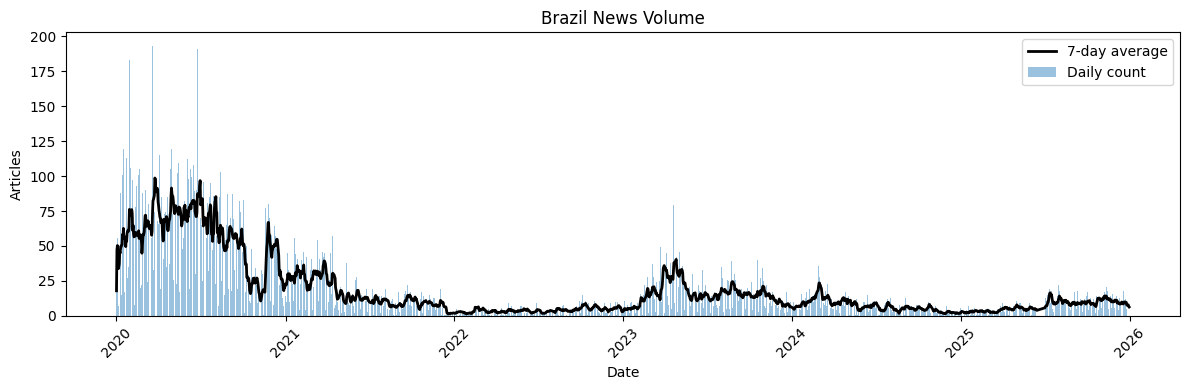

In [4]:
FILTERED_BRAZIL_PATH = Path("brazil_news")
FILTERED_BRAZIL_PATH.mkdir(exist_ok=True)

if not (FILTERED_BRAZIL_PATH / "brazil.parquet").exists():
    brazil_news = (
        fin_df
        .filter(
            pl.any_horizontal(
                pl.col("locations", "url", "themes", "v2themes", "title").str.contains_any(["brazil"], ascii_case_insensitive=True)
            )
        )
        .drop("date")
        .drop_nulls("title")
        .collect(engine="streaming")
    )

    brazil_news.write_parquet(FILTERED_BRAZIL_PATH / "brazil.parquet")

brazil_news = pl.read_parquet(FILTERED_BRAZIL_PATH / "brazil.parquet")

brazil_counts = (
    brazil_news
    .with_columns(pl.col("datetime").dt.date().alias("date"))
    .group_by("date")
    .len()
    .sort("date")
)

brazil_counts_pd = brazil_counts.to_pandas()
brazil_counts_pd["rolling_7d"] = brazil_counts_pd["len"].rolling(7, min_periods=1).mean()

print(brazil_news.group_by("source").len().sort(by="len", descending=True))

plt.figure(figsize=(12, 4))
plt.bar(brazil_counts_pd["date"], brazil_counts_pd["len"], label="Daily count", alpha=0.45)
plt.plot(brazil_counts_pd["date"], brazil_counts_pd["rolling_7d"], color="black", linewidth=2, label="7-day average")
plt.title("Brazil News Volume")
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Articles")
plt.legend()
plt.tight_layout()
plt.show()


# Modeling

## Use finBERT to extract sentiment from title column

In [5]:
MODEL = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
device = torch.device("cpu")
model.to(device)
model.eval()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [6]:
labels = ("negative", "neutral", "positive")

In [7]:
def predict_sentiment(texts: list[str], batch_size=32):

    results: list[dict[str, float]] = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        probs = F.softmax(outputs.logits, dim=1).cpu()

        for p in probs:
            results.append({
                "negative": p[0],
                "neutral": p[1],
                "positive": p[2],
                "sentiment_score": p[2] - p[0]
            })

    return results

In [8]:
if not "sentiment_score" in brazil_news.columns:

    titles = brazil_news["title"].to_list()

    sentiments = []

    BATCH_SIZE = 2048

    for i in tqdm(range(0, len(titles), BATCH_SIZE)):
        batch = titles[i:i+BATCH_SIZE]
        sentiments.extend(predict_sentiment(batch))
    
    sentiment_df = pl.DataFrame(sentiments)

    brazil_news = brazil_news.with_columns(sentiment_df)
    brazil_news.write_parquet(FILTERED_BRAZIL_PATH /  "brazil.parquet")

brazil_news = pl.read_parquet(FILTERED_BRAZIL_PATH /  "brazil.parquet")

## Download IBOVESPA from 2020 until 2025

In [9]:
ibov = pl.from_pandas(yf.download("^BVSP", start="2020-01-01", end="2026-01-01", progress=False, multi_level_index=False).reset_index())
ibov = ibov.rename({col:col.lower() for col in ibov.columns})

ibov = ibov.with_columns([
    pl.col("date").cast(pl.Date),
])

## Feature Engineering

In [10]:
# Aggregate Brazil news daily

daily_news = (
    brazil_news.with_columns(pl.col("datetime").dt.date().alias("date"))
    .group_by("date")
    .agg([
        pl.len().alias("news_volume"),
        pl.col("sentiment_score").mean().alias("sentiment_mean"),
        pl.col("positive").mean().alias("positive_mean"),
        pl.col("negative").mean().alias("negative_mean"),
        pl.col("tone").mean().alias("tone"),
    ])
    .with_columns(
        (pl.col("positive_mean") - pl.col("negative_mean")).alias("sentiment_imbalance"),
    )
    .sort("date")
)

# Keep only a small, interpretable feature set for easier testing.
# No-news trading days are filled with neutral news values instead of being dropped.

news_cols = [
    "news_volume",
    "sentiment_mean",
    "positive_mean",
    "negative_mean",
    "tone",
    "sentiment_imbalance",
]

required_model_cols = [
    "return",
    "target_return",
    "target_direction",
    "momentum_5d",
    "volatility_5d",
    "trend_20d",
    "drawdown_20d",
]

dataset = (
    ibov
    .join(daily_news, on="date", how="left")
    .sort("date")
    .with_columns([
        pl.col("news_volume").fill_null(0),
        pl.col("sentiment_mean").fill_null(0),
        pl.col("positive_mean").fill_null(0),
        pl.col("negative_mean").fill_null(0),
        pl.col("tone").fill_null(0),
        pl.col("sentiment_imbalance").fill_null(0),
    ])
    .with_columns([
        (pl.col("close") / pl.col("close").shift(1) - 1).alias("return"),
        (pl.col("news_volume") + 1).log().alias("log_news_volume"),
    ])
    .with_columns([
        pl.col("return").shift(-1).alias("target_return"),
        (pl.col("return").shift(-1) > 0).cast(pl.Int8).alias("target_direction"),
        pl.col("return").rolling_mean(5).alias("momentum_5d"),
        pl.col("return").rolling_std(5).alias("volatility_5d"),
        (pl.col("close") / pl.col("close").rolling_mean(20) - 1).alias("trend_20d"),
        (pl.col("close") / pl.col("close").rolling_max(20) - 1).alias("drawdown_20d"),
    ])
)

# Shift news features one trading day to avoid using same-day information.
lagged_news_cols = news_cols + ["log_news_volume"]

pdf = (
    dataset
    .with_columns([pl.col(c).shift(1) for c in lagged_news_cols])
    .drop_nulls(subset=required_model_cols)
    .to_pandas()
)


### Select features for training and prediction

In [11]:
sentiment_features = [
    "sentiment_mean",
    "sentiment_imbalance",
    "log_news_volume",
]

gdelt_tone_features = [
    "tone",
]

price_features = [
    "return",
    "momentum_5d",
    "volatility_5d",
    "trend_20d",
    "drawdown_20d",
]


### Create functions to run the classification and regression

In [12]:
tscv = TimeSeriesSplit(n_splits=5)
CLASSIFICATION_METRICS = ["accuracy_mean", "f1_mean", "roc_auc_mean"]
REGRESSION_METRICS = ["rmse_mean", "mae_mean", "r2_mean"]


def scale_train_test(X_train, X_test):
    scaler = StandardScaler()
    return (
        pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index),
        pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index),
    )


class TabularMLP(nn.Module):
    def __init__(self, n_features, hidden_size=16, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_features, hidden_size), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_size, 1))

    def forward(self, x):
        return self.net(x).squeeze(-1)


class MLPModel:
    def __init__(self, task, hidden_size=16, dropout=0.2, lr=1e-3, weight_decay=1e-4, epochs=100, patience=10, random_state=42):
        self.__dict__.update(locals())
        del self.__dict__["self"]

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        self.model_ = TabularMLP(X.shape[1], self.hidden_size, self.dropout)
        optimizer = torch.optim.AdamW(self.model_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        criterion = nn.BCEWithLogitsLoss() if self.task == "classification" else nn.MSELoss()
        X_tensor = torch.tensor(X.to_numpy(), dtype=torch.float32)
        y_tensor = torch.tensor(np.asarray(y), dtype=torch.float32)
        split_idx = max(1, int(len(X_tensor) * 0.8))
        train = X_tensor[:split_idx], y_tensor[:split_idx]
        val = X_tensor[split_idx:], y_tensor[split_idx:]
        best_loss, best_state, wait = float("inf"), None, 0

        for _ in range(self.epochs):
            self.model_.train()
            optimizer.zero_grad()
            loss = criterion(self.model_(train[0]), train[1])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model_.parameters(), max_norm=1.0)
            optimizer.step()

            self.model_.eval()
            with torch.no_grad():
                val_loss = criterion(self.model_(val[0]), val[1]).item() if len(val[0]) else loss.item()
            if val_loss < best_loss:
                best_loss = val_loss
                best_state = {k: v.detach().clone() for k, v in self.model_.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= self.patience:
                    break

        if best_state:
            self.model_.load_state_dict(best_state)
        return self

    def _predict_raw(self, X):
        self.model_.eval()
        with torch.no_grad():
            return self.model_(torch.tensor(X.to_numpy(), dtype=torch.float32)).numpy()

    def predict(self, X):
        raw = self._predict_raw(X)
        return (1 / (1 + np.exp(-raw)) >= 0.5).astype(int) if self.task == "classification" else raw

    def predict_proba(self, X):
        proba = 1 / (1 + np.exp(-self._predict_raw(X)))
        return np.column_stack([1 - proba, proba])


def make_classifiers(include_mlp=True):
    models = {
        "log_reg": LogisticRegression(max_iter=2000),
        "rf_clas": RandomForestClassifier(n_estimators=500, max_depth=6, random_state=42, n_jobs=-1),
        "xgb_clas": XGBClassifier(n_estimators=400, max_depth=4, learning_rate=0.03, subsample=0.8, colsample_bytree=0.8),
    }
    if include_mlp:
        models["mlp_clas"] = MLPModel(task="classification")
    return models


def make_regressors(include_mlp=True):
    models = {
        "lin_reg": LinearRegression(n_jobs=-1),
        "rf_reg": RandomForestRegressor(n_estimators=500, max_depth=6, random_state=42, n_jobs=-1),
        "xgb_reg": XGBRegressor(n_estimators=400, max_depth=4, learning_rate=0.03),
    }
    if include_mlp:
        models["mlp_reg"] = MLPModel(task="regression")
    return models


def summarize_metrics(fold_metrics):
    fold_df = pd.DataFrame(fold_metrics)
    return {f"{metric}_{stat}": getattr(fold_df[metric], stat)() for metric in fold_df.columns for stat in ("mean", "std")}


def run_cv(model, X, y, metric_fn, prediction_fn):
    fold_metrics, y_true, y_pred, extra = [], [], [], []
    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = scale_train_test(X.iloc[train_idx], X.iloc[test_idx])
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        model.fit(X_train, y_train)
        pred, extra_pred = prediction_fn(model, X_test)
        fold_metrics.append(metric_fn(y_test, pred, extra_pred))
        y_true.append(y_test)
        y_pred.append(pred)
        if extra_pred is not None:
            extra.append(extra_pred)
    return summarize_metrics(fold_metrics), pd.concat(y_true), np.concatenate(y_pred), extra


def run_classification(model, X, y):
    def predict(model, X_test):
        proba = model.predict_proba(X_test)[:, 1]
        return model.predict(X_test), proba

    def metrics(y_test, pred, proba):
        return {"accuracy": accuracy_score(y_test, pred), "f1": f1_score(y_test, pred), "roc_auc": roc_auc_score(y_test, proba)}

    summary, y_true, y_pred, proba = run_cv(model, X, y, metrics, predict)
    return summary, y_true, y_pred, np.concatenate(proba)


def run_regression(model, X, y):
    def predict(model, X_test):
        return model.predict(X_test), None

    def metrics(y_test, pred, _):
        return {"rmse": root_mean_squared_error(y_test, pred), "mae": mean_absolute_error(y_test, pred), "r2": r2_score(y_test, pred)}

    summary, y_true, y_pred, _ = run_cv(model, X, y, metrics, predict)
    return summary, y_true, y_pred


def evaluate_models(X, y_cls, y_reg, classifiers=None, regressors=None):
    results, importances = {}, {}
    for task, models, runner, y, sort_col in [
        ("clf", classifiers or make_classifiers(), run_classification, y_cls, "accuracy_mean"),
        ("reg", regressors or make_regressors(), run_regression, y_reg, "r2_mean"),
    ]:
        rows, imps = [], {}
        for name, model in models.items():
            metrics, *_ = runner(model, X, y)
            rows.append({"model": name, **metrics})
            if hasattr(model, "feature_importances_"):
                imps[name] = pd.Series(model.feature_importances_, index=X.columns)
        results[task] = pd.DataFrame(rows).sort_values(sort_col, ascending=False)
        importances[task] = imps
    return results["clf"], results["reg"], importances["clf"], importances["reg"]


def regression_baselines(y):
    zero_pred = np.zeros(len(y))
    return {"rmse_mean": root_mean_squared_error(y, zero_pred), "mae_mean": mean_absolute_error(y, zero_pred), "r2_mean": r2_score(y, zero_pred)}


def style_axis(ax, title, xlabel=None, ylabel=None, grid_axis="y"):
    ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(axis=grid_axis, alpha=0.3)


def plot_metric_bars(ax, df, metric_cols, title):
    x, width = np.arange(len(df)), 0.8 / len(metric_cols)
    for i, col in enumerate(metric_cols):
        ax.bar(x + (i - (len(metric_cols) - 1) / 2) * width, df[col], width, yerr=df.get(col.replace("_mean", "_std")), capsize=4, label=col.replace("_mean", "").upper())
    ax.set_xticks(x, df["model"])
    ax.legend(title="Metric")
    style_axis(ax, title, "Model", "Score")


def plot_single_metric_bar(ax, df, metric, title, baseline=None):
    ax.bar(df["model"], df[metric], yerr=df.get(metric.replace("_mean", "_std")), capsize=4)
    if baseline is not None:
        ax.axhline(baseline, color="black", linestyle="--", linewidth=1, label="Baseline")
        ax.legend()
    ax.tick_params(axis="x", rotation=20)
    style_axis(ax, title, "Model", metric.replace("_mean", "").upper())


def plot_importance(ax, importance, title, top_n=15):
    if importance:
        pd.concat(importance, axis=1).fillna(0).mean(axis=1).sort_values(ascending=False).head(top_n).plot.bar(ax=ax)
    style_axis(ax, title)


def plot_model_results(feature_cols, title, y_dir, y_ret):
    clf_df, reg_df, clf_importance, reg_importance = evaluate_models(pdf[feature_cols], y_dir, y_ret)
    reg_baseline = regression_baselines(y_ret)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(title)
    plot_metric_bars(axes[0, 0], clf_df, CLASSIFICATION_METRICS, "Classifier Performance")
    for ax, metric in zip(axes.flat[1:4], REGRESSION_METRICS):
        plot_single_metric_bar(ax, reg_df, metric, f"Regressor {metric.replace('_mean', '').upper()}", reg_baseline[metric])
    plot_importance(axes[1, 1], clf_importance, "Feature Importance - Tree Classifiers")
    plot_importance(axes[1, 2], reg_importance, "Feature Importance - Tree Regressors")
    plt.tight_layout()
    plt.show()
    return clf_df, reg_df, clf_importance, reg_importance


def collect_experiment_results(experiments):
    rows = {"clf": [], "reg": []}
    for experiment, result in experiments.items():
        clf_df, reg_df = result[:2]
        rows["clf"].append(clf_df.assign(experiment=experiment))
        rows["reg"].append(reg_df.assign(experiment=experiment))
    return pd.concat(rows["clf"], ignore_index=True), pd.concat(rows["reg"], ignore_index=True)


def rank_experiments(experiments, classifier_metric="roc_auc_mean", regressor_metric="rmse_mean"):
    clf_results, reg_results = collect_experiment_results(experiments)
    clf_cols = list(dict.fromkeys(["experiment", "model", classifier_metric, *CLASSIFICATION_METRICS]))
    reg_cols = list(dict.fromkeys(["experiment", "model", regressor_metric, *REGRESSION_METRICS]))
    return (
        clf_results.sort_values(classifier_metric, ascending=False).loc[:, clf_cols].reset_index(drop=True),
        reg_results.sort_values(regressor_metric).loc[:, reg_cols].reset_index(drop=True),
        clf_results,
        reg_results,
    )


def plot_result_heatmap(ax, results, metric, title):
    table = results.pivot(index="experiment", columns="model", values=metric)
    image = ax.imshow(table.values, aspect="auto")
    ax.set_xticks(range(len(table.columns)), table.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(table.index)), table.index)
    for row in range(table.shape[0]):
        for col in range(table.shape[1]):
            ax.text(col, row, f"{table.iloc[row, col]:.3f}", ha="center", va="center", fontsize=8)
    plt.colorbar(image, ax=ax, label=metric)
    style_axis(ax, title)


def plot_top_results(ax, ranking, metric, title, top_n=10):
    top = ranking.head(top_n)
    labels = top["experiment"].astype(str) + " | " + top["model"].astype(str)
    ax.barh(np.arange(len(top)), pd.to_numeric(top[metric], errors="coerce"))
    ax.set_yticks(np.arange(len(top)), labels)
    ax.invert_yaxis()
    style_axis(ax, title, metric, grid_axis="x")


def plot_experiment_comparison(experiments, title="Experiment comparison"):
    clf_ranking, reg_ranking, clf_results, reg_results = rank_experiments(experiments)
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    fig.suptitle(title)
    plot_top_results(axes[0, 0], clf_ranking, "roc_auc_mean", "Top classifiers by ROC AUC")
    plot_top_results(axes[0, 1], reg_ranking, "rmse_mean", "Top regressors by RMSE")
    plot_result_heatmap(axes[1, 0], clf_results, "roc_auc_mean", "Classifier ROC AUC by experiment")
    plot_result_heatmap(axes[1, 1], reg_results, "rmse_mean", "Regressor RMSE by experiment")
    plt.tight_layout()
    plt.show()
    print("Classifier ranking")
    display(clf_ranking)
    print("Regressor ranking")
    display(reg_ranking)
    return clf_ranking, reg_ranking, clf_results, reg_results


## Evaluating models

In [13]:
y_dir = pdf["target_direction"]
y_ret = pdf["target_return"]

### Testing only return

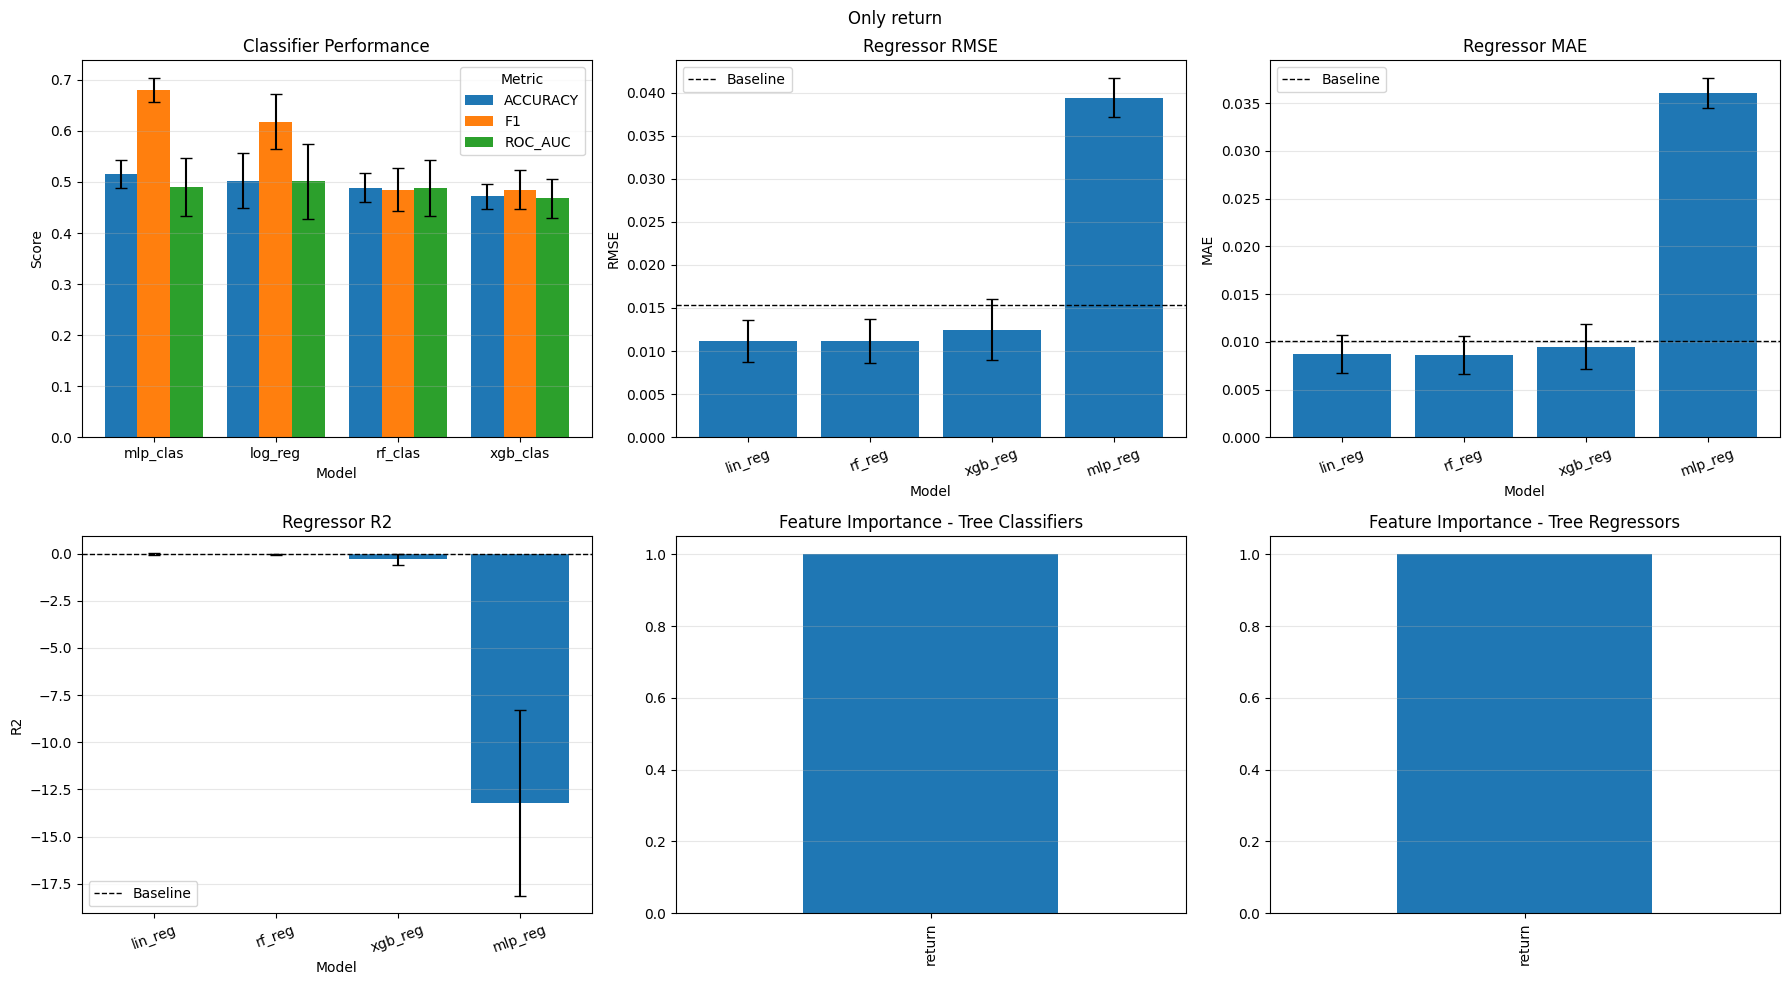

In [14]:
return_results = plot_model_results(["return"], "Only return", y_dir, y_ret)

### Testing only sentiment score

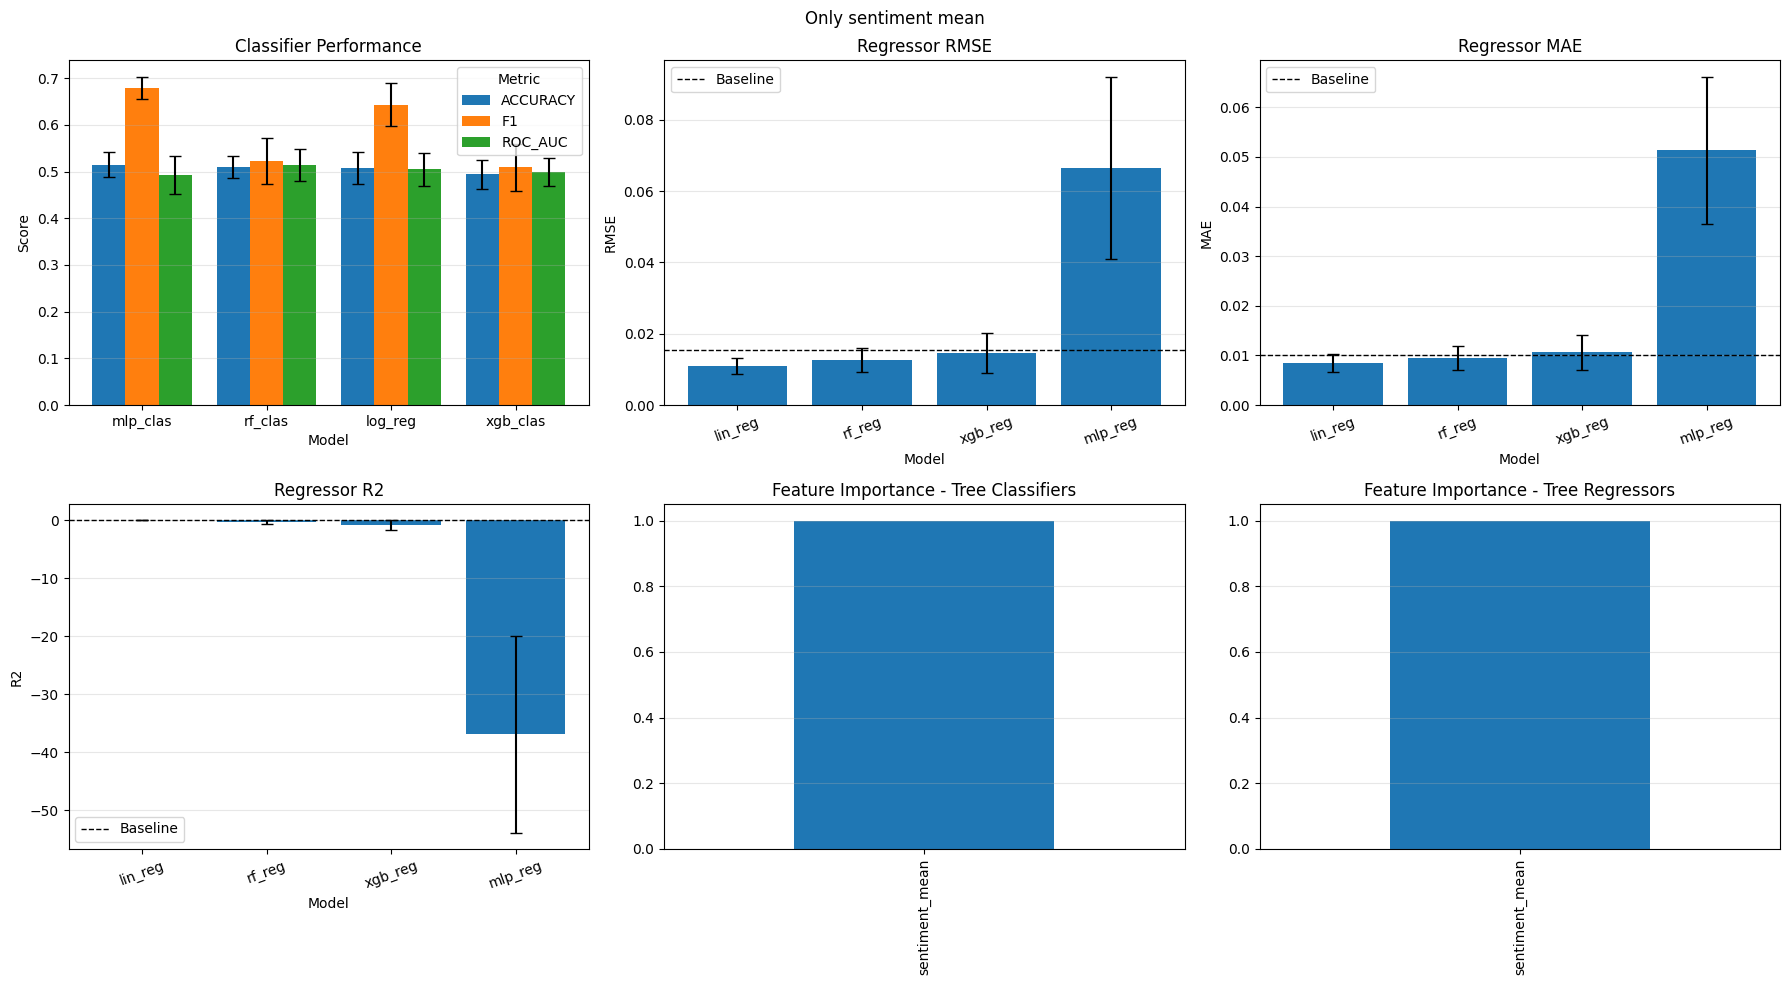

In [15]:
sentiment_mean_results = plot_model_results(["sentiment_mean"], "Only sentiment mean", y_dir, y_ret)

### Testing only tone

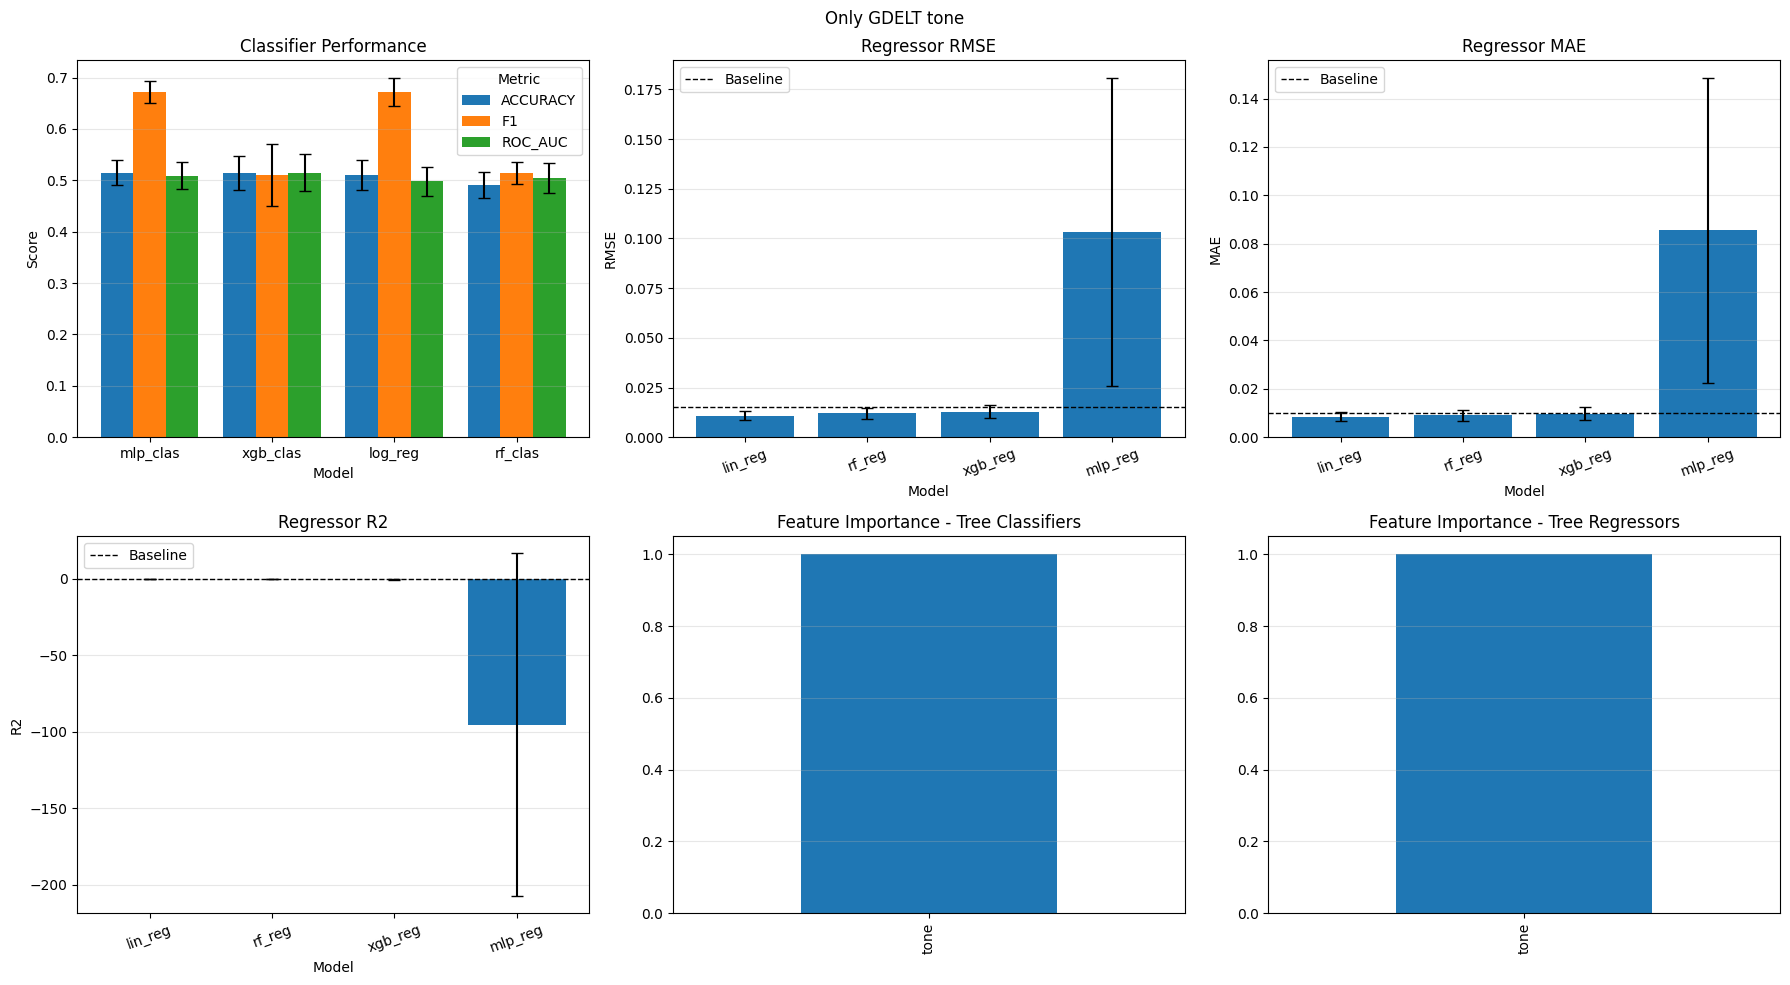

In [16]:
tone_results = plot_model_results(gdelt_tone_features, "Only GDELT tone", y_dir, y_ret)


### Testing all sentiment related features

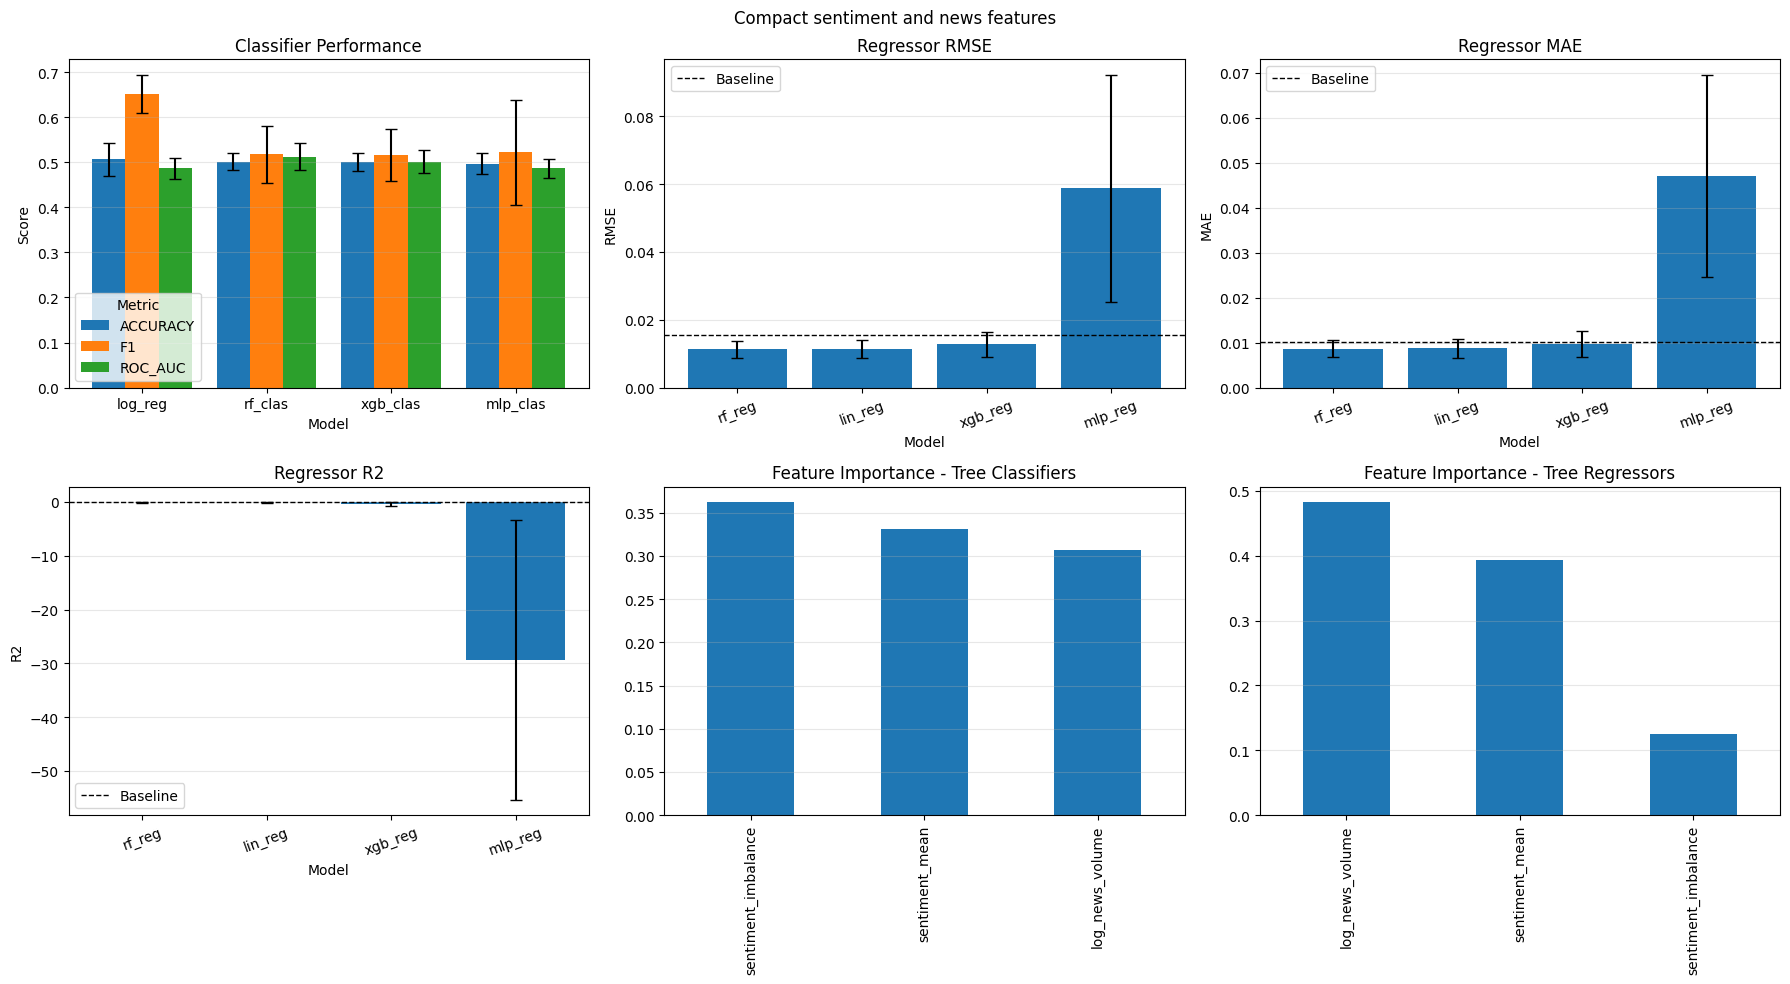

In [17]:
sentiment_results = plot_model_results(sentiment_features, "Compact sentiment and news features", y_dir, y_ret)


### Testing all price related features

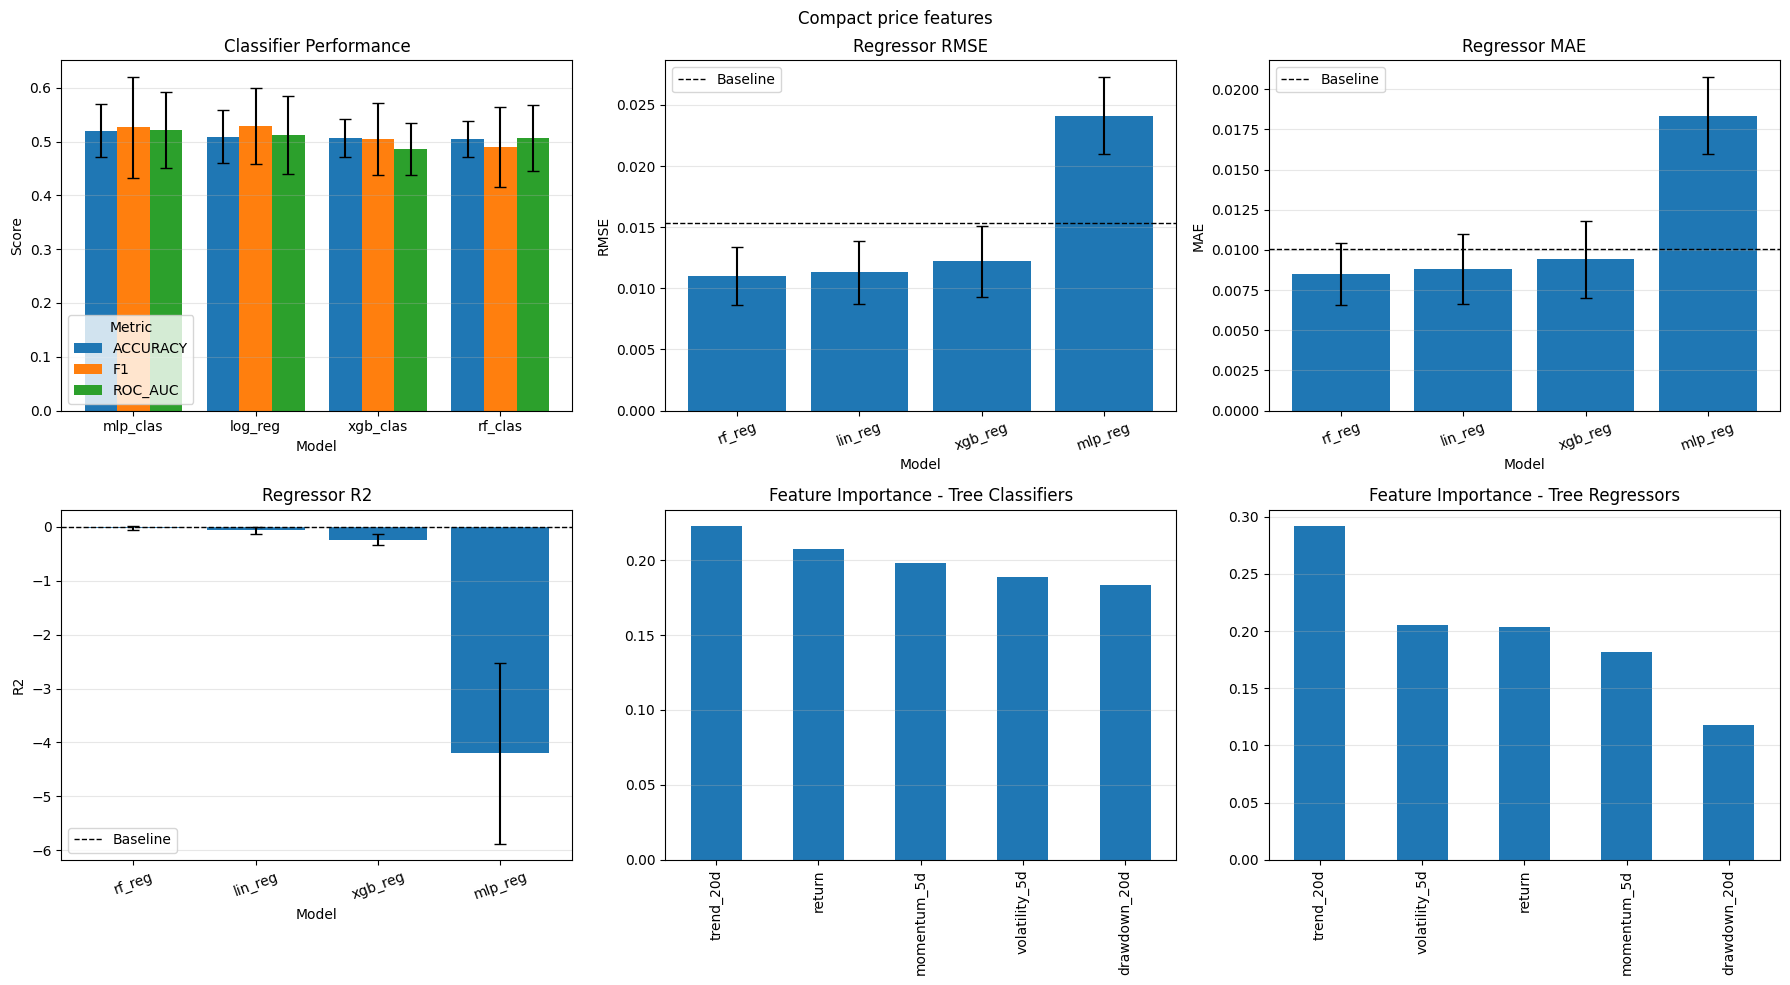

In [18]:
price_results = plot_model_results(price_features, "Compact price features", y_dir, y_ret)


### Testing sentiment, tone and price features

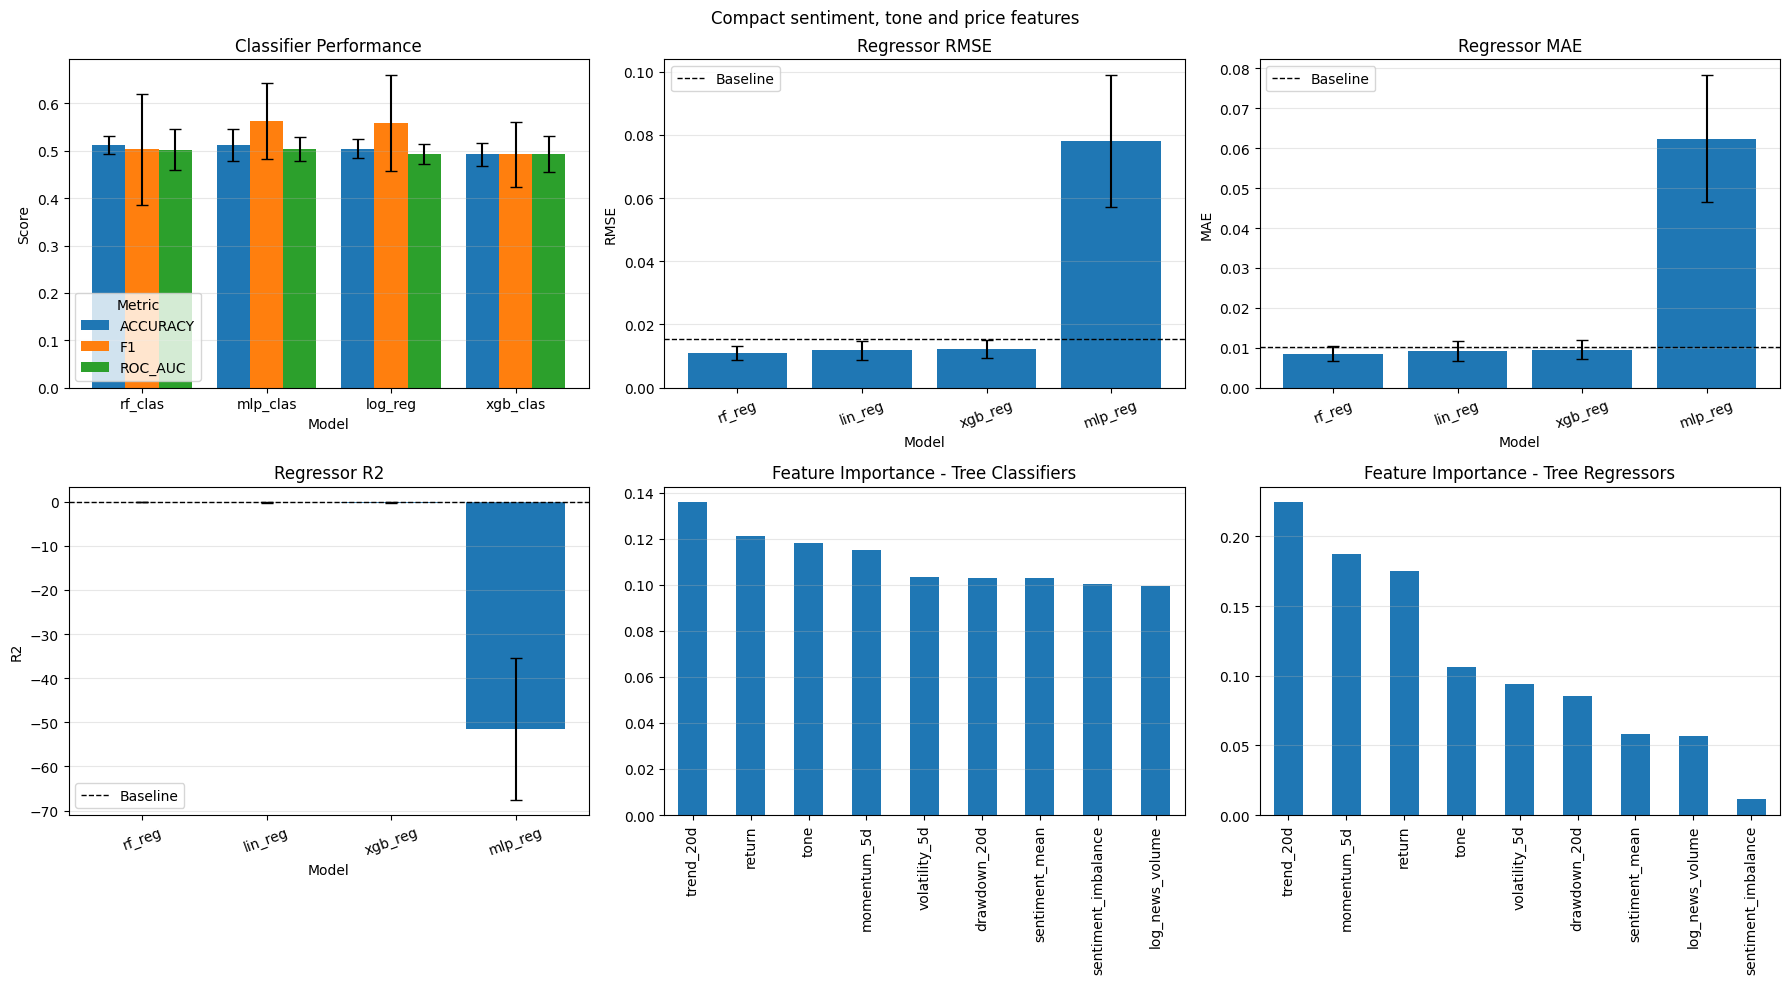

In [19]:
all_feature_results = plot_model_results(sentiment_features + gdelt_tone_features + price_features, "Compact sentiment, tone and price features", y_dir, y_ret)


### Compare all standard tests


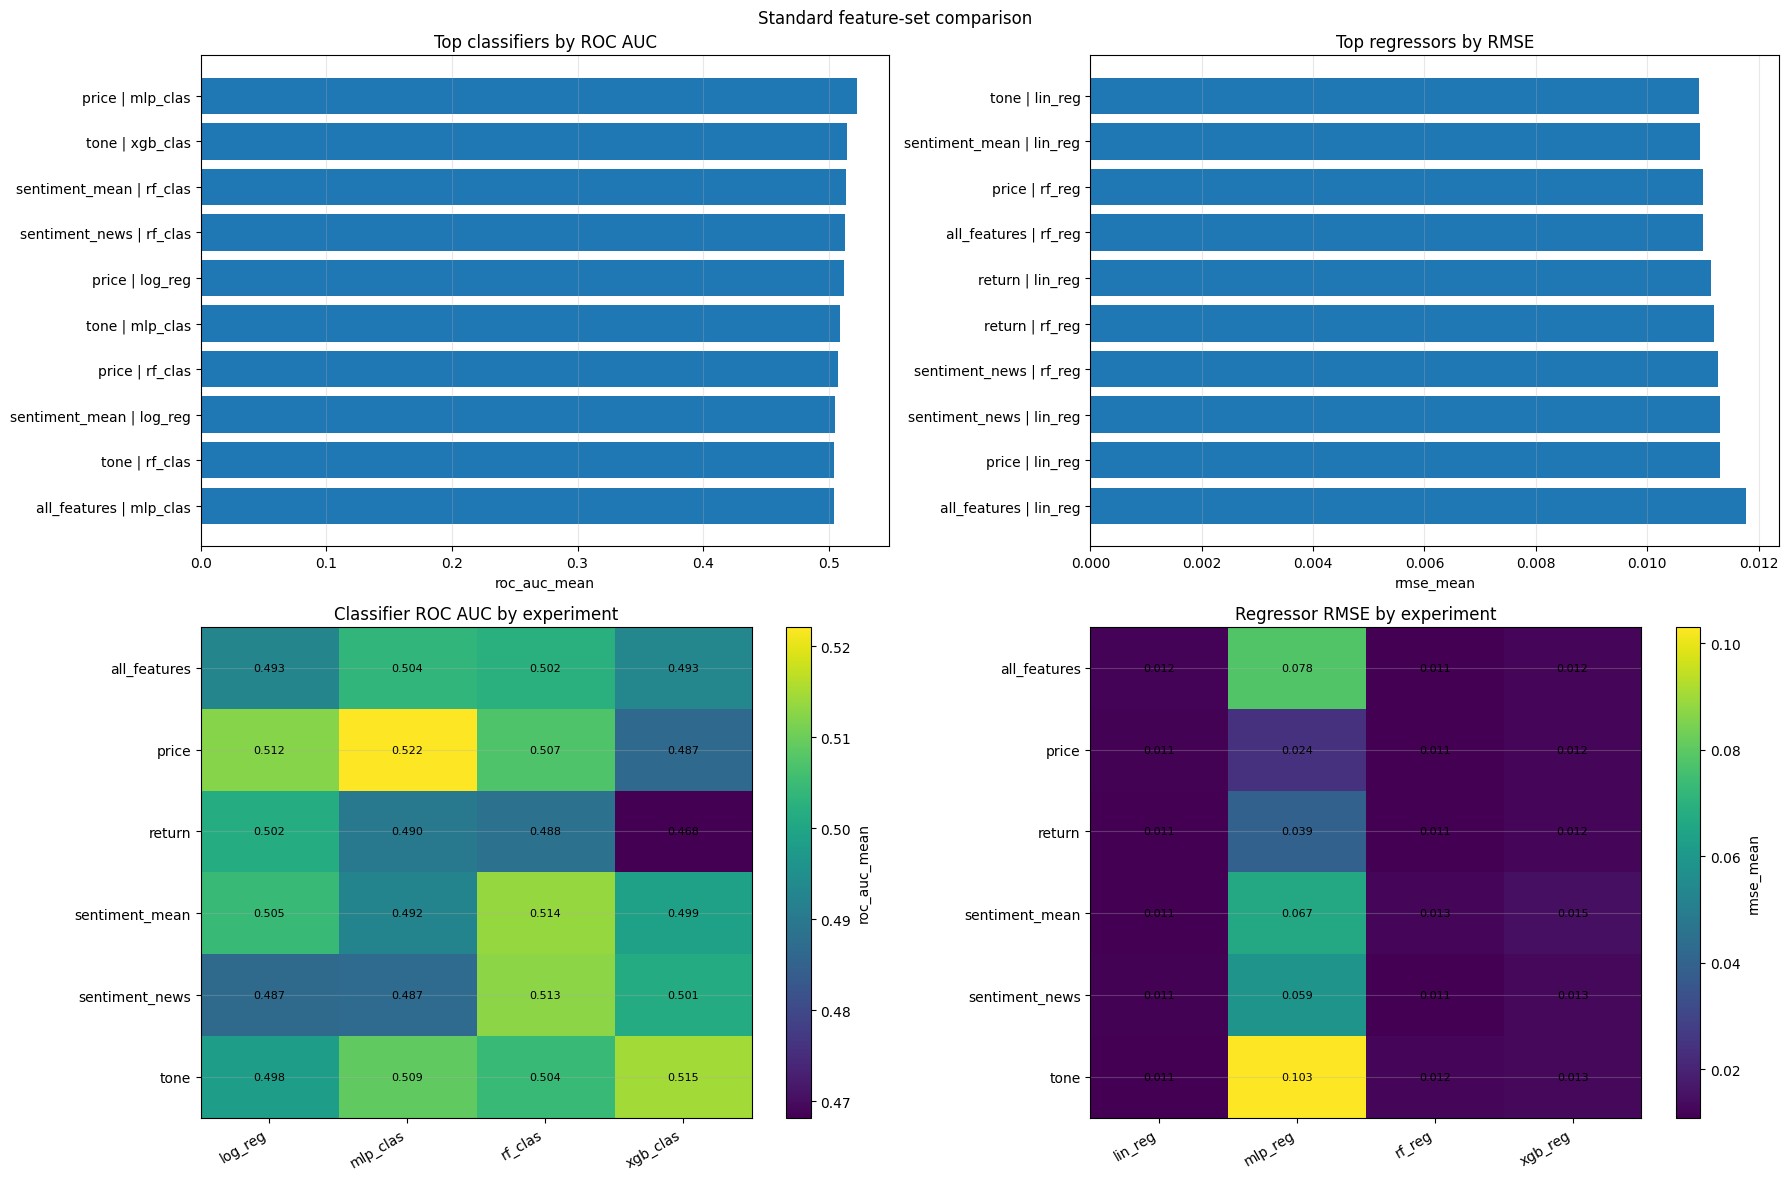

Classifier ranking


,experiment,model,roc_auc_mean,accuracy_mean,f1_mean
0,price,mlp_clas,0.522145,0.520816,0.526807
1,tone,xgb_clas,0.514640,0.513469,0.509750
2,sentiment_mean,rf_clas,0.513697,0.509388,0.522341
3,sentiment_news,rf_clas,0.512700,0.501224,0.517384
4,price,log_reg,0.512441,0.509388,0.529104
5,tone,mlp_clas,0.508900,0.514286,0.672193
6,price,rf_clas,0.507199,0.505306,0.490441
7,sentiment_mean,log_reg,0.504568,0.507755,0.643461
8,tone,rf_clas,0.504470,0.491429,0.514127
9,all_features,mlp_clas,0.503743,0.511837,0.562715


Regressor ranking


,experiment,model,rmse_mean,mae_mean,r2_mean
0,tone,lin_reg,0.010924,0.008466,-0.005000
1,sentiment_mean,lin_reg,0.010944,0.008475,-0.008244
2,price,rf_reg,0.010999,0.008498,-0.016009
3,all_features,rf_reg,0.011008,0.008494,-0.019346
4,return,lin_reg,0.011137,0.008725,-0.041005
5,return,rf_reg,0.011199,0.008637,-0.048868
6,sentiment_news,rf_reg,0.011269,0.008689,-0.063792
7,sentiment_news,lin_reg,0.011302,0.008733,-0.067304
8,price,lin_reg,0.011315,0.008800,-0.070201
9,all_features,lin_reg,0.011781,0.009181,-0.150652


In [20]:
standard_experiments = {
    "return": return_results,
    "sentiment_mean": sentiment_mean_results,
    "tone": tone_results,
    "sentiment_news": sentiment_results,
    "price": price_results,
    "all_features": all_feature_results,
}

standard_comparison = plot_experiment_comparison(standard_experiments, "Standard feature-set comparison")


## Removing features using Recursive Feature Elimination

In [21]:
def run_rfecv(model, X, y, scoring):
    selector = RFECV(estimator=model, step=1, cv=TimeSeriesSplit(n_splits=5), scoring=scoring, n_jobs=-1)
    selector.fit(X, y)
    return selector


def get_feature_importance(model, feature_names):
    if hasattr(model, "coef_"):
        return pd.Series(np.abs(model.coef_).flatten(), index=feature_names)
    if hasattr(model, "feature_importances_"):
        return pd.Series(model.feature_importances_, index=feature_names)
    raise ValueError("Model does not expose feature importance")


def evaluate_rfecv_models(X, y_cls, y_reg):
    configs = [
        ("clf", make_classifiers(False), y_cls, "accuracy", run_classification, "accuracy_mean"),
        ("reg", make_regressors(False), y_reg, "neg_mean_squared_error", run_regression, "r2_mean"),
    ]
    outputs = {}
    for task, models, y, scoring, runner, sort_col in configs:
        rows, curves, importance = [], {}, {}
        for name, model in models.items():
            selector = run_rfecv(model, X, y, scoring)
            best_features = X.columns[selector.support_].tolist()
            curves[name] = selector.cv_results_["mean_test_score"]
            model.fit(X[best_features], y)
            importance[name] = get_feature_importance(model, best_features)
            metrics, *_ = runner(model, X[best_features], y)
            rows.append({"model": name, "features": best_features, **metrics})
        outputs[task] = pd.DataFrame(rows).sort_values(sort_col, ascending=False), curves, importance

    clf_df, clf_curves, clf_importance = outputs["clf"]
    reg_df, reg_curves, reg_importance = outputs["reg"]
    return clf_df, reg_df, clf_curves, reg_curves, clf_importance, reg_importance


def plot_rfecv_curves(ax, curves, title, ylabel):
    for name, scores in curves.items():
        ax.plot(range(1, len(scores) + 1), scores, label=name)
    ax.legend()
    style_axis(ax, title, "Number of Selected Features", ylabel)


def plot_importance_heatmap(ax, importance, title):
    imp_df = pd.DataFrame(importance).fillna(0)
    imp_df = imp_df.div(imp_df.max().replace(0, np.nan), axis=1).fillna(0)
    image = ax.imshow(imp_df.values, aspect="auto")
    ax.set_yticks(range(len(imp_df.index)), imp_df.index)
    ax.set_xticks(range(len(imp_df.columns)), imp_df.columns)
    plt.colorbar(image, ax=ax, label="Normalized Importance")
    style_axis(ax, title, "Model", "Feature")


def plot_rfecv_results(feature_cols, title, y_dir, y_ret):
    results = evaluate_rfecv_models(pdf[feature_cols], y_dir, y_ret)
    clf_df, reg_df, clf_curves, reg_curves, clf_importance, reg_importance = results
    reg_baseline = regression_baselines(y_ret)
    fig, axes = plt.subplots(4, 2, figsize=(16, 22))
    fig.suptitle(title)
    plot_metric_bars(axes[0, 0], clf_df, CLASSIFICATION_METRICS, "Classifier Performance")
    plot_rfecv_curves(axes[0, 1], clf_curves, "RFECV Curves - Classifiers", "Cross-Validated Accuracy")
    plot_single_metric_bar(axes[1, 0], reg_df, "rmse_mean", "Regressor RMSE", reg_baseline["rmse_mean"])
    plot_single_metric_bar(axes[1, 1], reg_df, "mae_mean", "Regressor MAE", reg_baseline["mae_mean"])
    plot_single_metric_bar(axes[2, 0], reg_df, "r2_mean", "Regressor R2", reg_baseline["r2_mean"])
    plot_rfecv_curves(axes[2, 1], reg_curves, "RFECV Curves - Regressors", "Cross-Validated Score (neg MSE)")
    plot_importance_heatmap(axes[3, 0], clf_importance, "Feature Importance Heatmap - Classifiers")
    plot_importance_heatmap(axes[3, 1], reg_importance, "Feature Importance Heatmap - Regressors")
    plt.tight_layout()
    plt.show()
    return results


### Testing only sentiment related features

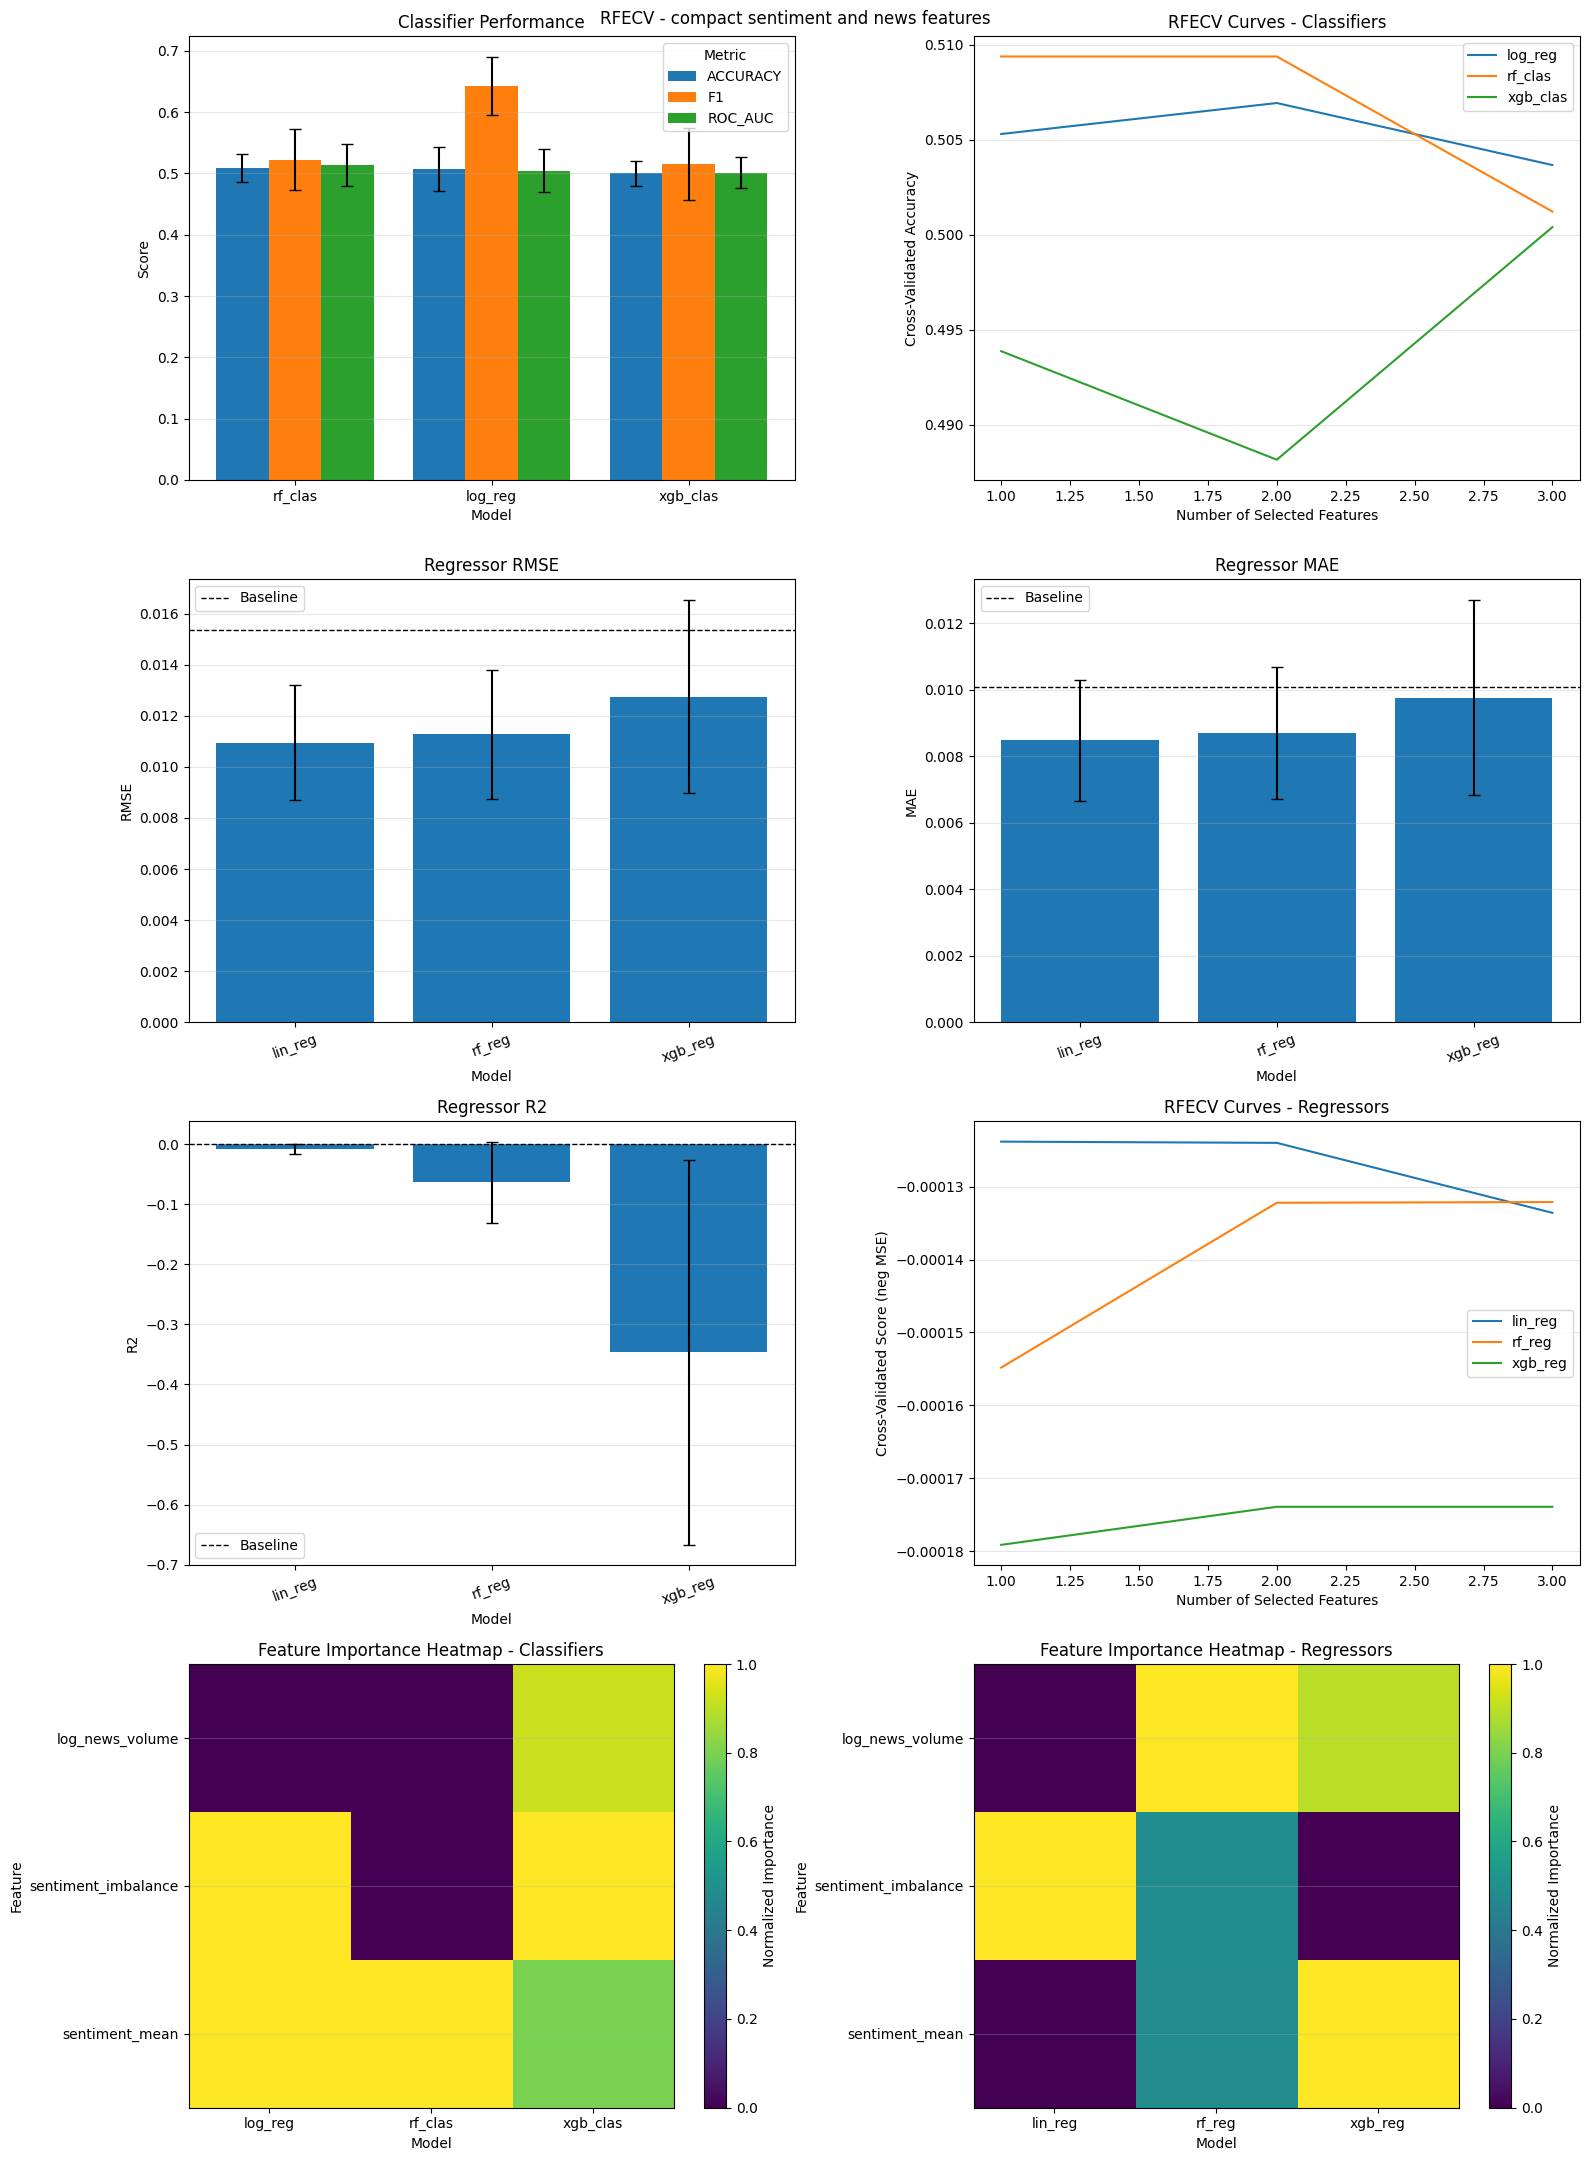

In [22]:
sentiment_rfecv_results = plot_rfecv_results(sentiment_features, "RFECV - compact sentiment and news features", y_dir, y_ret)


### Testing only price related features

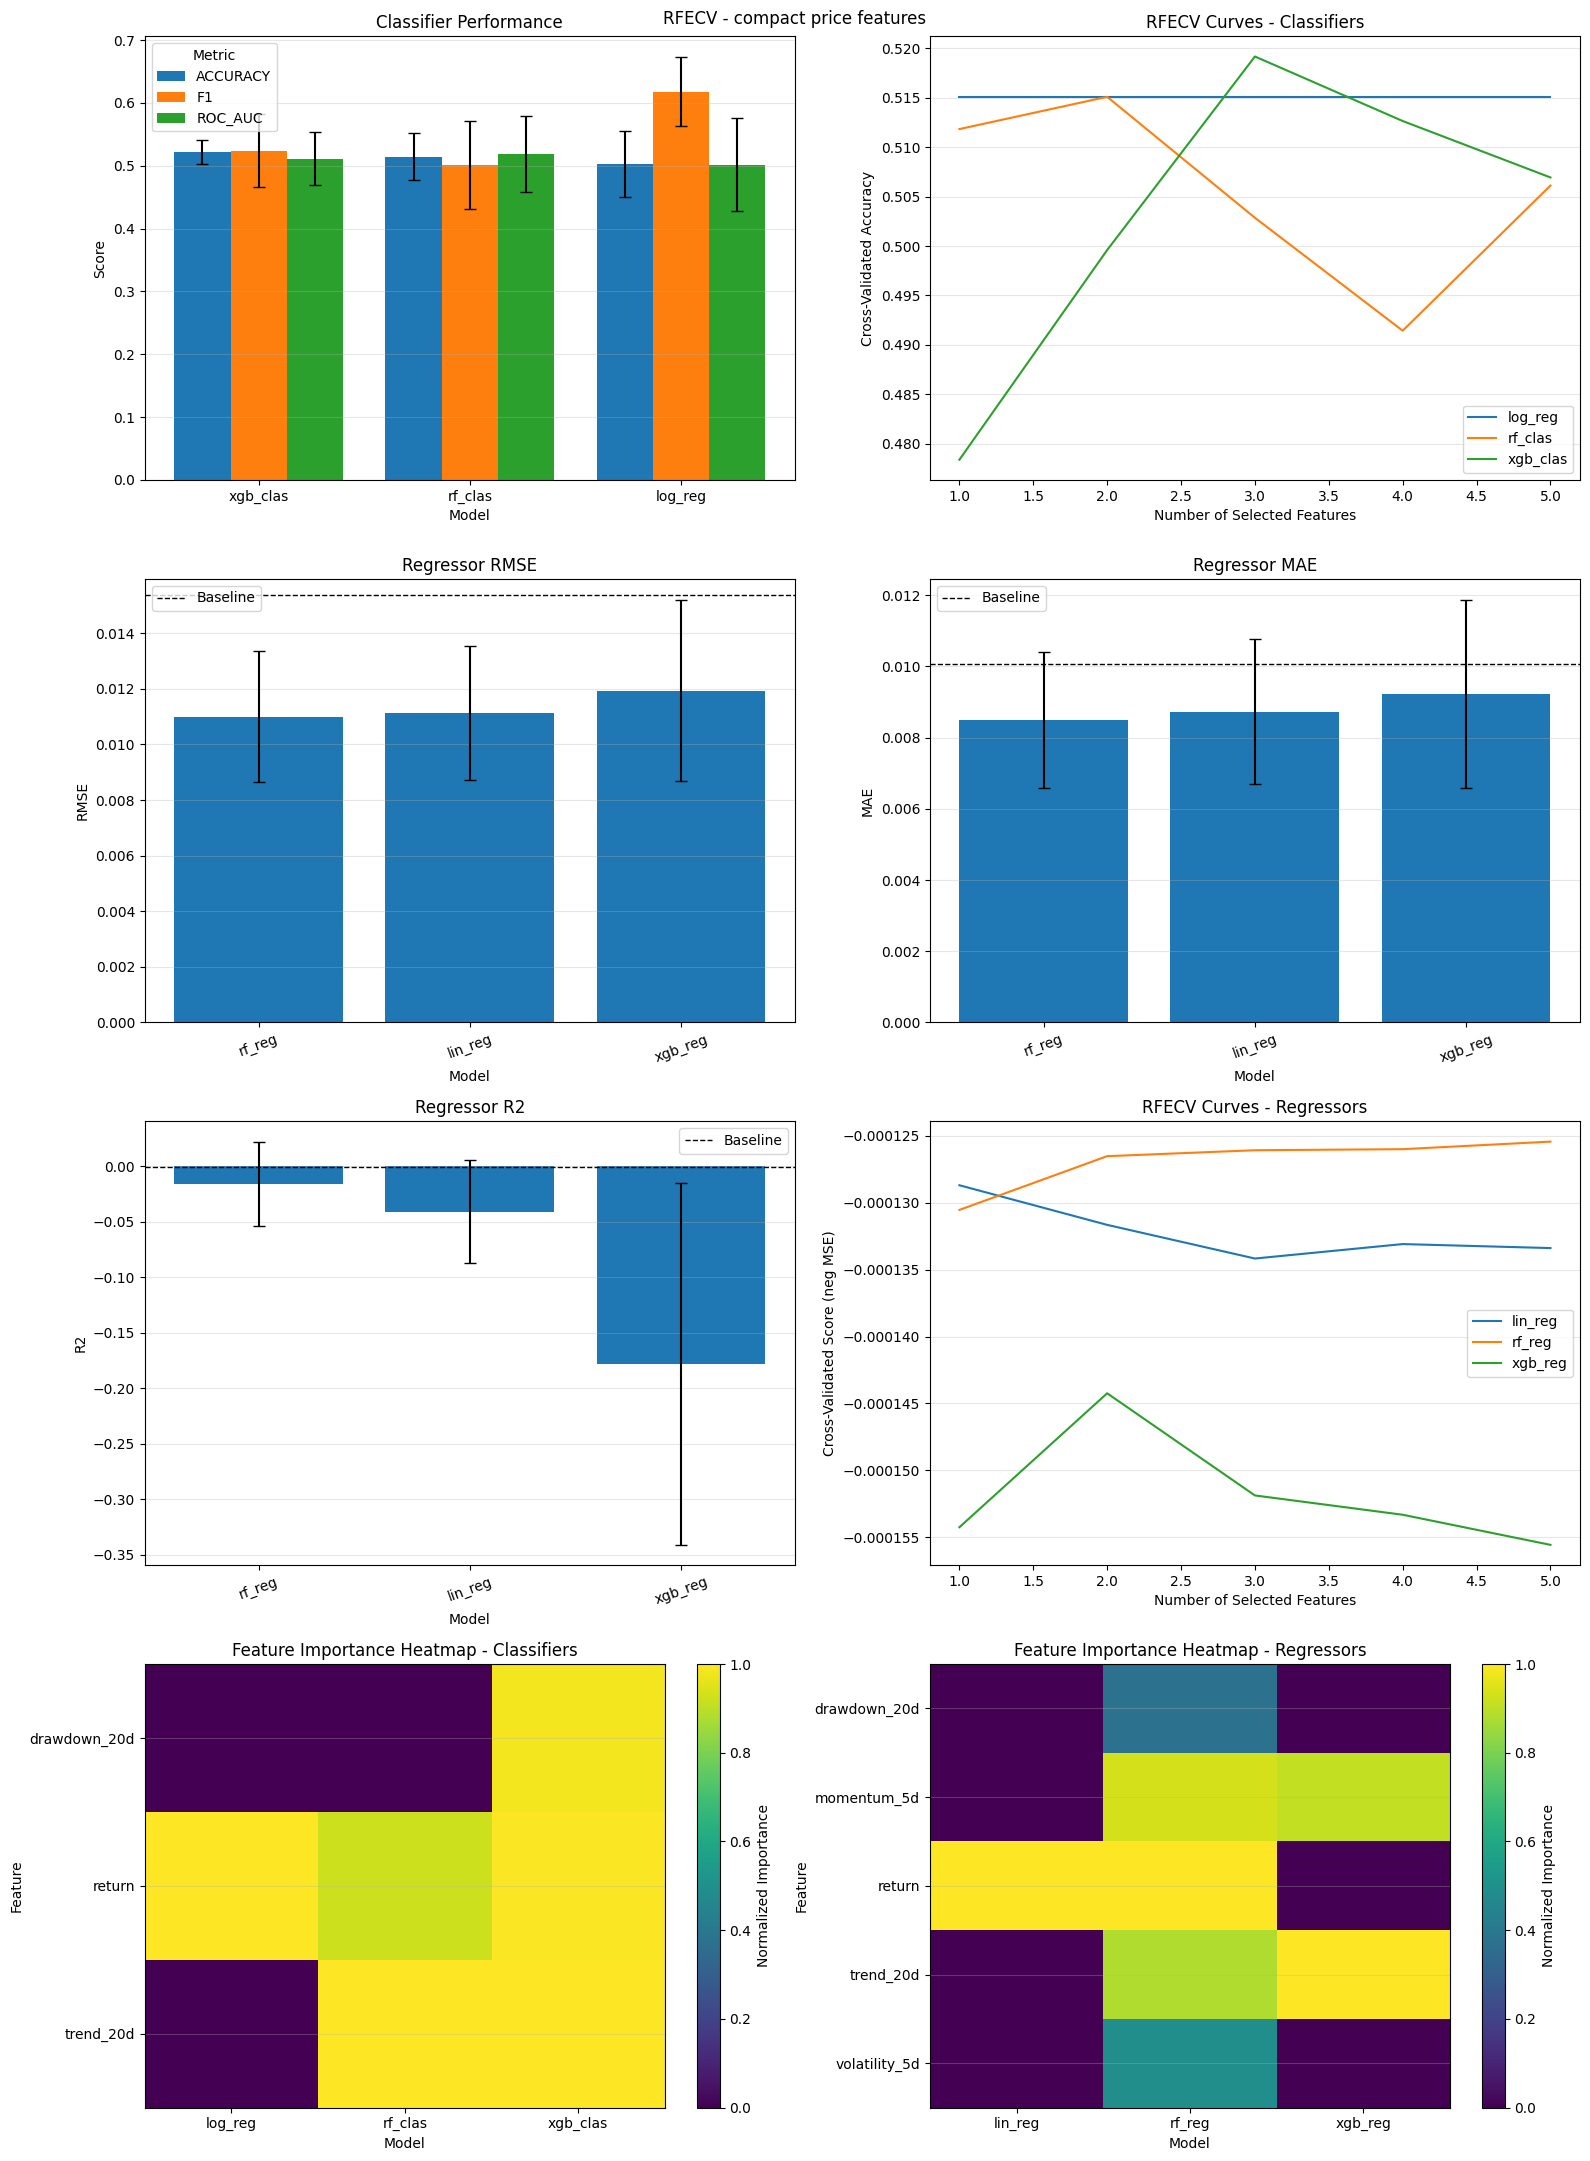

In [23]:
price_rfecv_results = plot_rfecv_results(price_features, "RFECV - compact price features", y_dir, y_ret)


### Testing sentiment, tone and price features

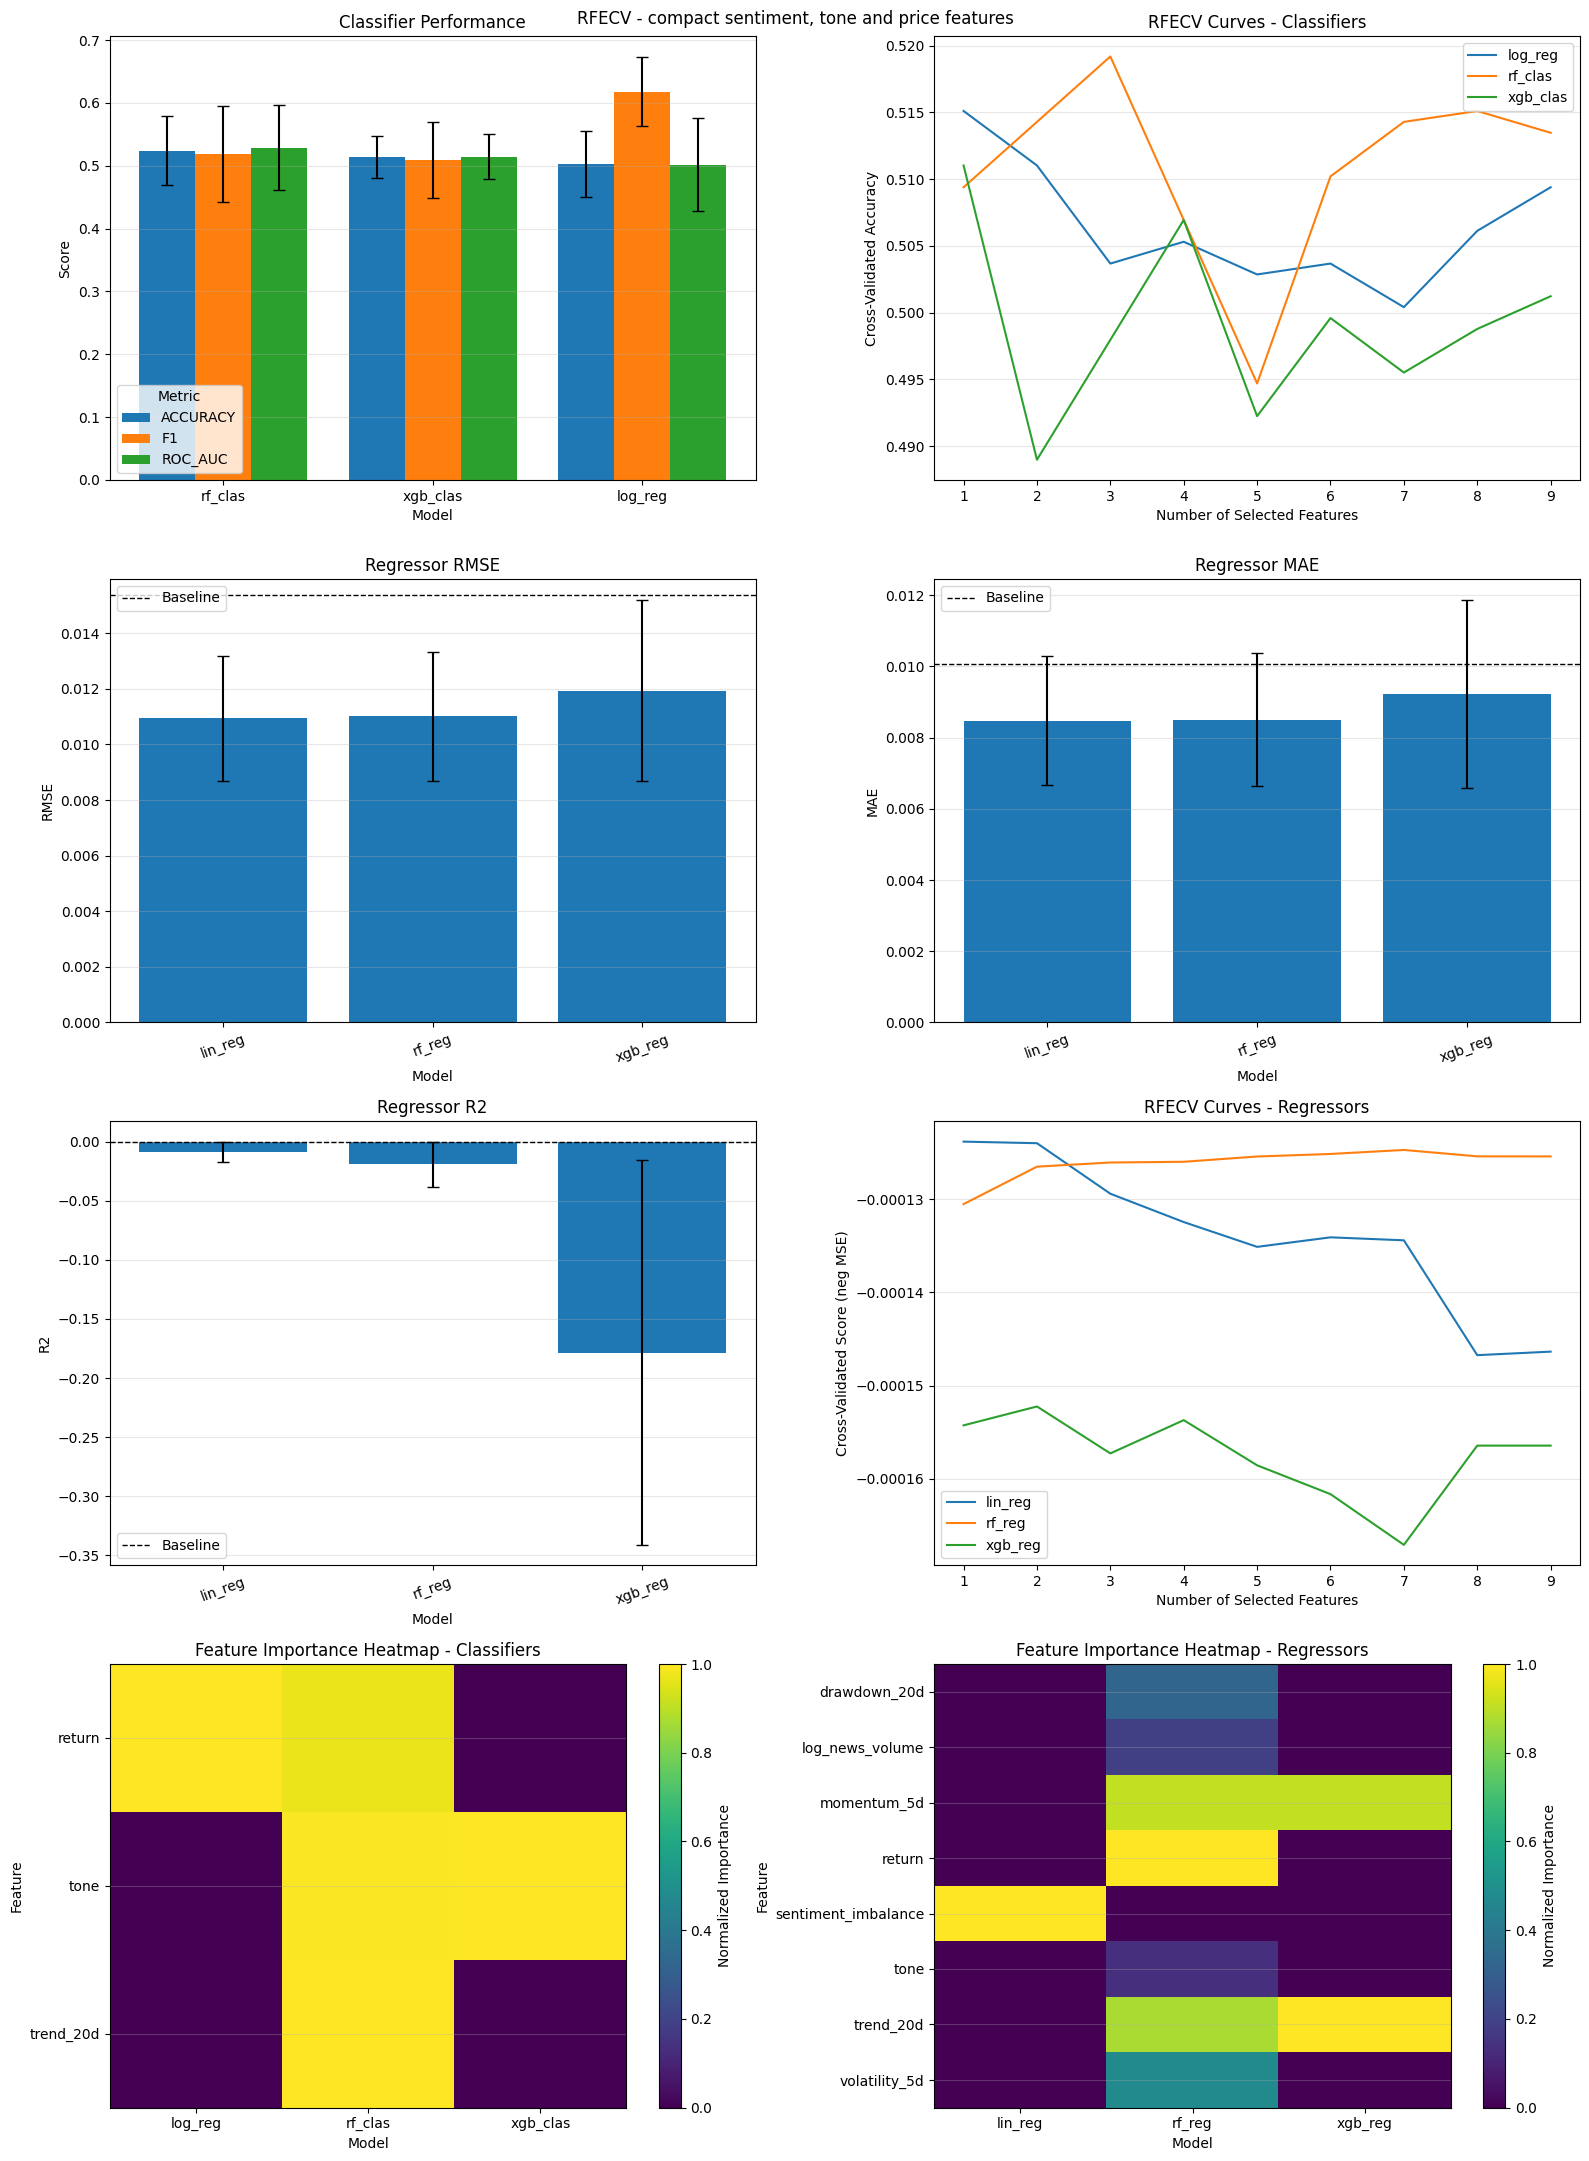

In [24]:
all_feature_rfecv_results = plot_rfecv_results(sentiment_features + price_features + gdelt_tone_features, "RFECV - compact sentiment, tone and price features", y_dir, y_ret)


### Compare RFECV tests


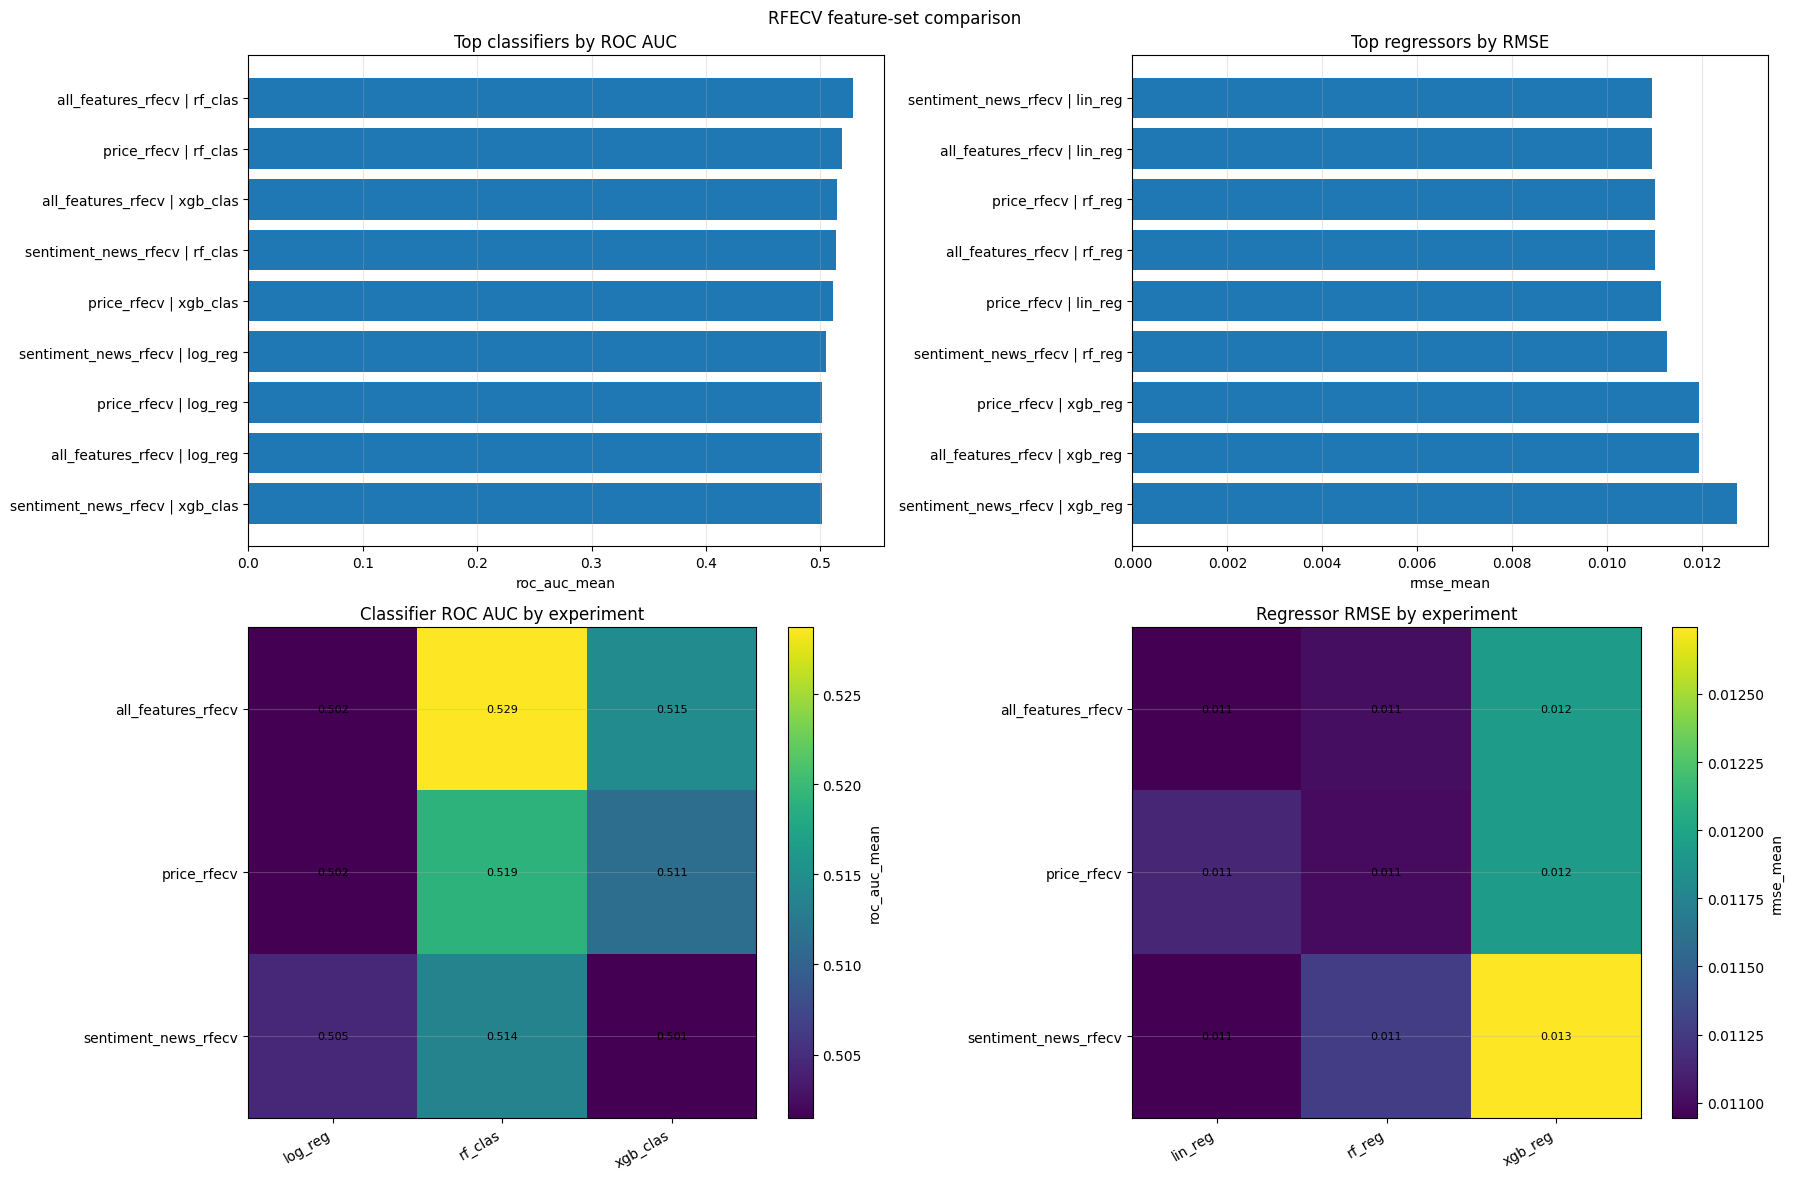

Classifier ranking


,experiment,model,roc_auc_mean,accuracy_mean,f1_mean
0,all_features_rfecv,rf_clas,0.528742,0.524082,0.518614
1,price_rfecv,rf_clas,0.519143,0.514286,0.501824
2,all_features_rfecv,xgb_clas,0.514640,0.513469,0.509750
3,sentiment_news_rfecv,rf_clas,0.513697,0.509388,0.522341
4,price_rfecv,xgb_clas,0.511285,0.522449,0.523832
5,sentiment_news_rfecv,log_reg,0.504568,0.506939,0.642609
6,price_rfecv,log_reg,0.501540,0.502857,0.618023
7,all_features_rfecv,log_reg,0.501540,0.502857,0.618023
8,sentiment_news_rfecv,xgb_clas,0.501481,0.500408,0.515958


Regressor ranking


,experiment,model,rmse_mean,mae_mean,r2_mean
0,sentiment_news_rfecv,lin_reg,0.010944,0.008475,-0.008244
1,all_features_rfecv,lin_reg,0.010944,0.008475,-0.008244
2,price_rfecv,rf_reg,0.010999,0.008498,-0.016009
3,all_features_rfecv,rf_reg,0.011009,0.008506,-0.018980
4,price_rfecv,lin_reg,0.011137,0.008725,-0.041005
5,sentiment_news_rfecv,rf_reg,0.011269,0.008689,-0.063792
6,price_rfecv,xgb_reg,0.011940,0.009221,-0.178478
7,all_features_rfecv,xgb_reg,0.011940,0.009221,-0.178478
8,sentiment_news_rfecv,xgb_reg,0.012746,0.009761,-0.346772


In [25]:
rfecv_experiments = {
    "sentiment_news_rfecv": sentiment_rfecv_results,
    "price_rfecv": price_rfecv_results,
    "all_features_rfecv": all_feature_rfecv_results,
}

rfecv_comparison = plot_experiment_comparison(rfecv_experiments, "RFECV feature-set comparison")


### Final ranking across all experiments


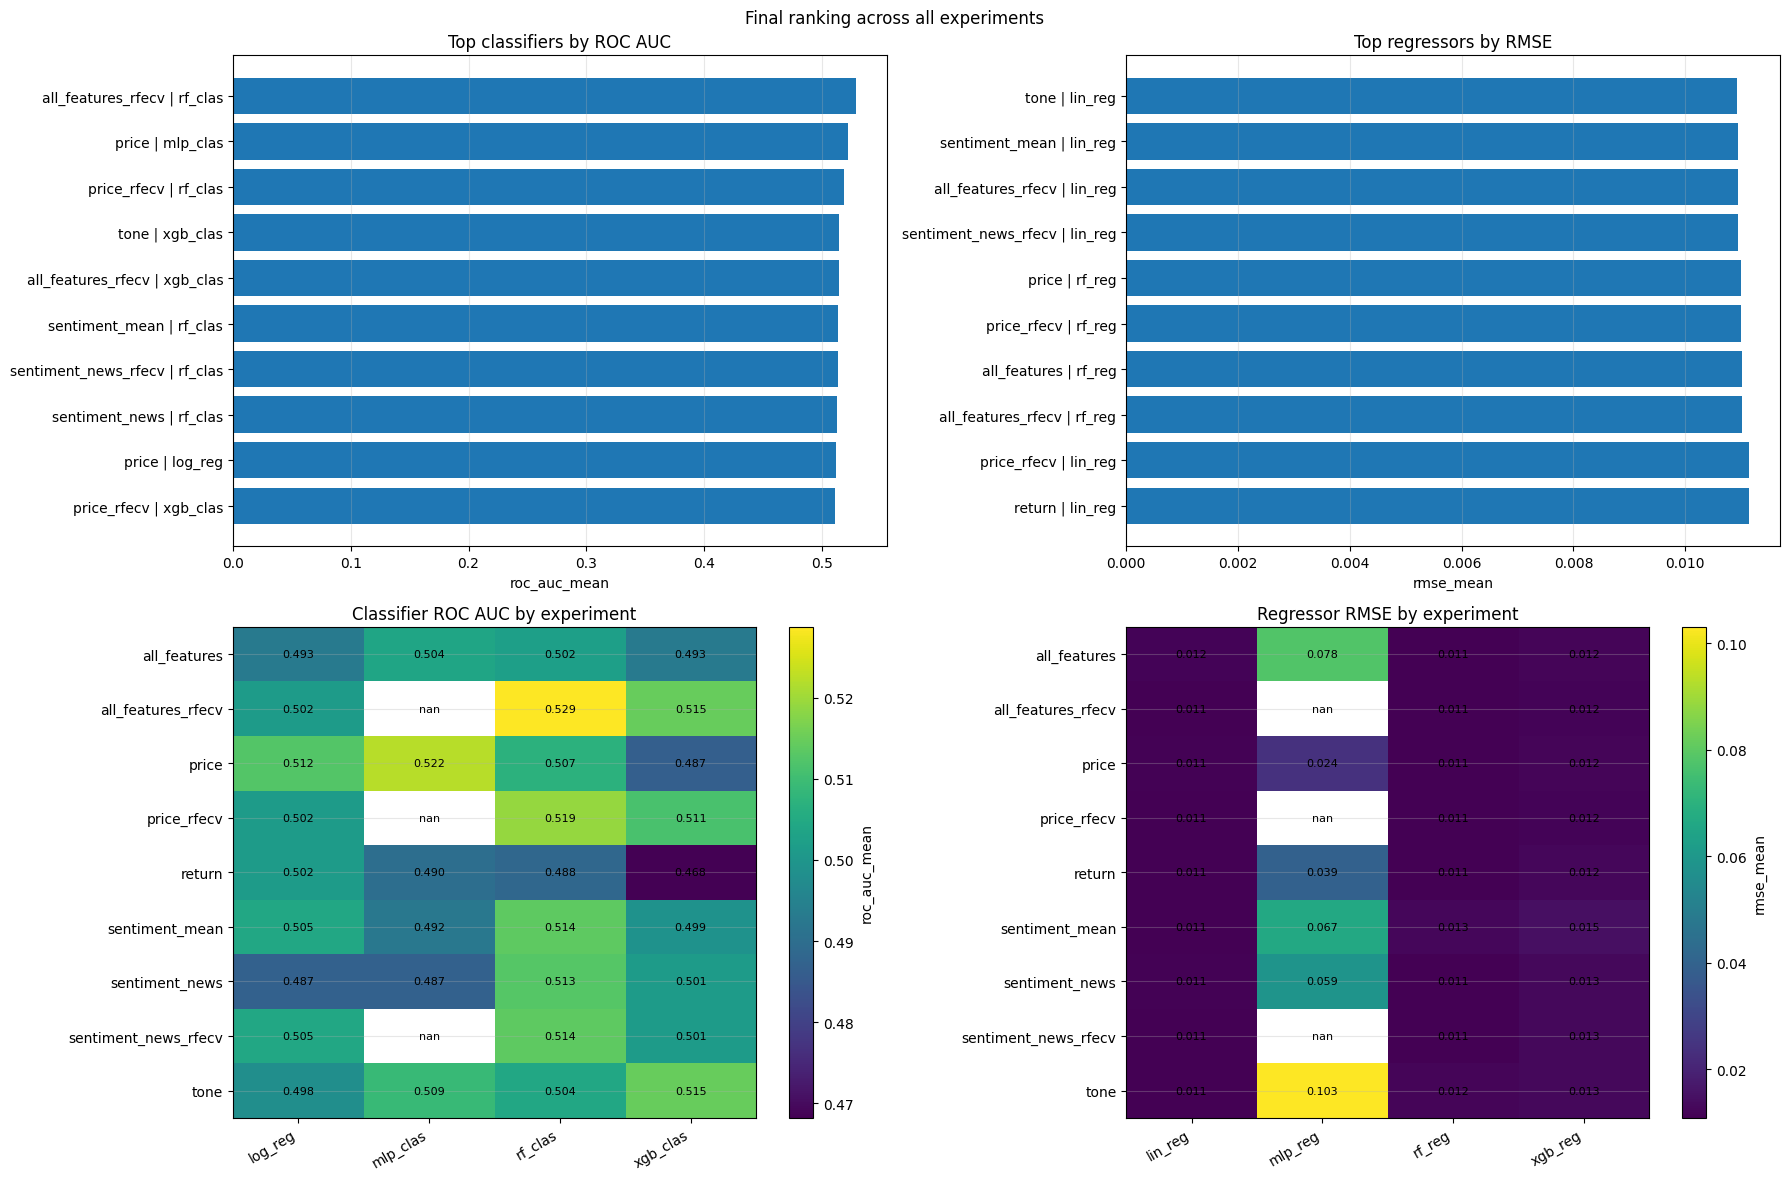

Classifier ranking


,experiment,model,roc_auc_mean,accuracy_mean,f1_mean
0,all_features_rfecv,rf_clas,0.528742,0.524082,0.518614
1,price,mlp_clas,0.522145,0.520816,0.526807
2,price_rfecv,rf_clas,0.519143,0.514286,0.501824
3,tone,xgb_clas,0.514640,0.513469,0.509750
4,all_features_rfecv,xgb_clas,0.514640,0.513469,0.509750
5,sentiment_mean,rf_clas,0.513697,0.509388,0.522341
6,sentiment_news_rfecv,rf_clas,0.513697,0.509388,0.522341
7,sentiment_news,rf_clas,0.512700,0.501224,0.517384
8,price,log_reg,0.512441,0.509388,0.529104
9,price_rfecv,xgb_clas,0.511285,0.522449,0.523832


Regressor ranking


,experiment,model,rmse_mean,mae_mean,r2_mean
0,tone,lin_reg,0.010924,0.008466,-0.005000
1,sentiment_mean,lin_reg,0.010944,0.008475,-0.008244
2,all_features_rfecv,lin_reg,0.010944,0.008475,-0.008244
3,sentiment_news_rfecv,lin_reg,0.010944,0.008475,-0.008244
4,price,rf_reg,0.010999,0.008498,-0.016009
5,price_rfecv,rf_reg,0.010999,0.008498,-0.016009
6,all_features,rf_reg,0.011008,0.008494,-0.019346
7,all_features_rfecv,rf_reg,0.011009,0.008506,-0.018980
8,price_rfecv,lin_reg,0.011137,0.008725,-0.041005
9,return,lin_reg,0.011137,0.008725,-0.041005


Best classifier: rf_clas with all_features_rfecv (ROC AUC = 0.529)
Best regressor: lin_reg with tone (RMSE = 0.01092)


In [26]:
all_experiments = {
    **standard_experiments,
    **rfecv_experiments,
}

final_comparison = plot_experiment_comparison(all_experiments, "Final ranking across all experiments")
final_classifier_ranking, final_regressor_ranking = final_comparison[:2]

best_classifier = final_classifier_ranking.iloc[0]
best_regressor = final_regressor_ranking.iloc[0]

print(
    f"Best classifier: {best_classifier['model']} with {best_classifier['experiment']} "
    f"(ROC AUC = {best_classifier['roc_auc_mean']:.3f})"
)
print(
    f"Best regressor: {best_regressor['model']} with {best_regressor['experiment']} "
    f"(RMSE = {best_regressor['rmse_mean']:.5f})"
)
